# **===========================================================================================================================================================** #
# **Machine Learning: Unit 3 End Project** #
# **===========================================================================================================================================================** #

## <u>**Notebook Setup**</u> ##

In [1]:
#Import Statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.base import (
    BaseEstimator, 
    TransformerMixin
)

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    mean_squared_error, 
    root_mean_squared_error, 
    r2_score,
    silhouette_score,
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    KBinsDiscretizer,
    PowerTransformer,
    QuantileTransformer,
    MinMaxScaler,
    StandardScaler,
    FunctionTransformer,
    OrdinalEncoder,
    OneHotEncoder,
    LabelEncoder,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    Ridge, 
    Lasso,
    ElasticNet
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier
)

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering, 
    FeatureAgglomeration,
    DBSCAN
)

from sklearn.model_selection import(
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold
)

from scipy.stats import t
from scipy.stats import (
    boxcox, 
    yeojohnson, 
    shapiro
)

from scipy.cluster.hierarchy import (
    dendrogram, 
    linkage
)

import scipy.sparse as sp
from scipy.sparse.linalg import svds

from sklearn.impute import (
    SimpleImputer,
    KNNImputer
)

from sklearn.metrics.pairwise import (
    cosine_similarity
)

from sklearn.decomposition import (
    PCA,
    TruncatedSVD,
    NMF
)

from sklearn.manifold import TSNE

from statsmodels.nonparametric.smoothers_lowess import lowess

from kneed import KneeLocator

from imblearn.over_sampling import SMOTE

## <u>**1. Data Import and Initial Exploratory Data Analysis**</u> ##

### **Initial Data Load** ###

In [2]:
# Import data into DataFrame
# Renamed CSV file is assumed to live in same folder as my notebook
df_employeeTurnOver = pd.read_csv("HR_comma_sep.csv")

# Make a copy of the dataframe to save dataframe pre-modificiations
# Keep the original unmodified data for reference purposes.
df_employeeTurnOver_initial = df_employeeTurnOver.copy(deep=True)

# Create a globel name for the data set
data_set_name = 'Employee Turnover'

pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)


### **EDA Utility Functions** ###

In [3]:
data_set_name = ''
target_label = ''

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(df_target, display_table=True):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print()
    print(df_info)
    print()

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    if display_table == True:
        print('Display Analysis Results in Tables')
        DisplayTable(df_stats, f'{data_set_name} Description Statistics')
        print()
        DisplayTable(df_info, f'{data_set_name} Basic Information')
        print()
        DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
        print()
        DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
        print()
        DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
        print()
        DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
        print()    
        DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
        
    print()

#### **Data Statistics** ####


***********************************
Description Stats
***********************************

                 Feature    count unique    top  freq        mean        std  \
0     satisfaction_level  14999.0    NaN    NaN   NaN    0.612834   0.248631   
1        last_evaluation  14999.0    NaN    NaN   NaN    0.716102   0.171169   
2         number_project  14999.0    NaN    NaN   NaN    3.803054   1.232592   
3   average_montly_hours  14999.0    NaN    NaN   NaN  201.050337  49.943099   
4     time_spend_company  14999.0    NaN    NaN   NaN    3.498233   1.460136   
5          Work_accident  14999.0    NaN    NaN   NaN     0.14461   0.351719   
6                   left  14999.0    NaN    NaN   NaN    0.238083   0.425924   
7  promotion_last_5years  14999.0    NaN    NaN   NaN    0.021268   0.144281   
8                  sales    14999     10  sales  4140         NaN        NaN   
9                 salary    14999      3    low  7316         NaN        NaN   

    min    25%    50%    75

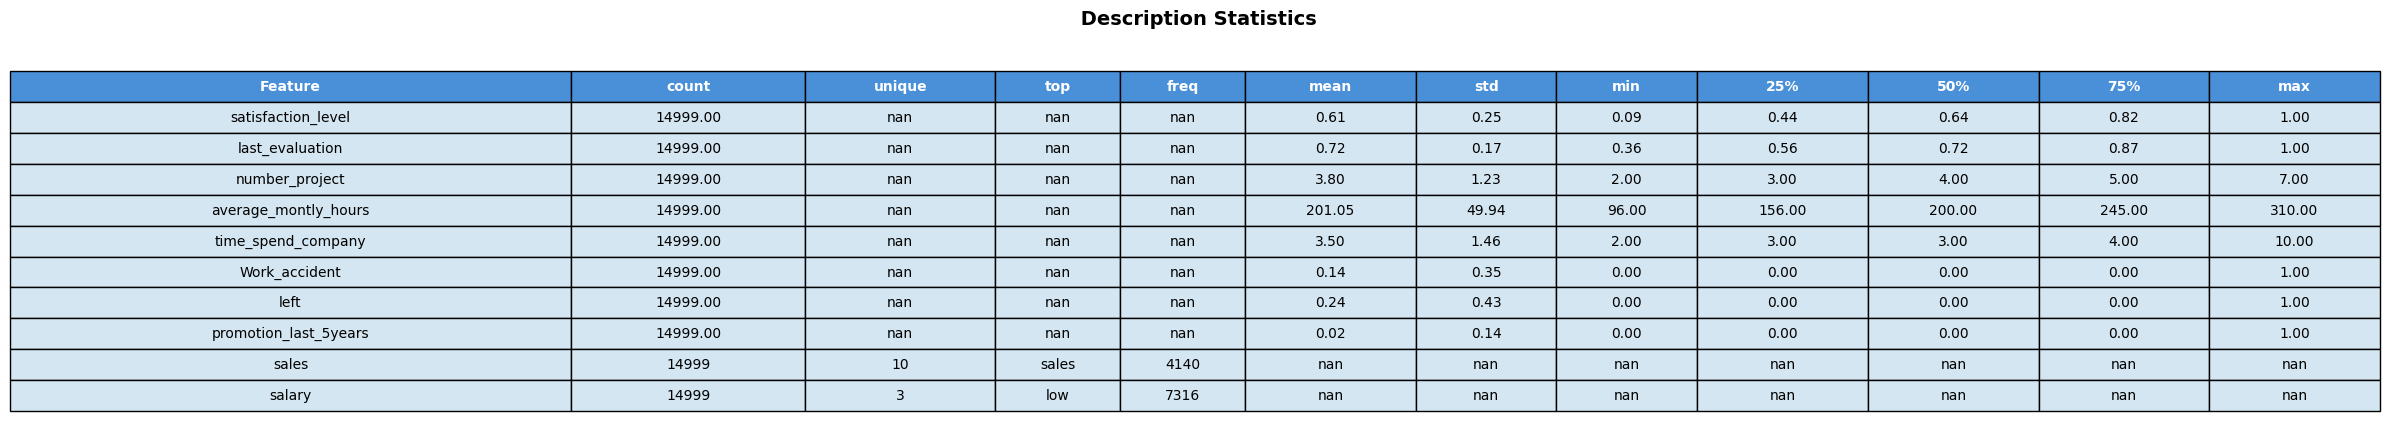

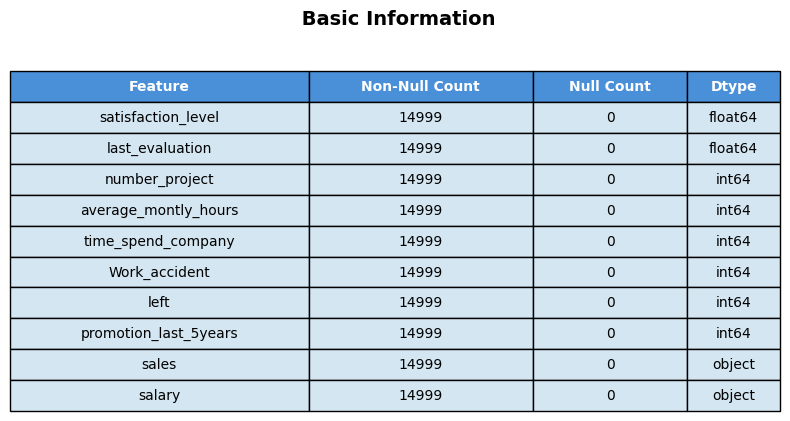

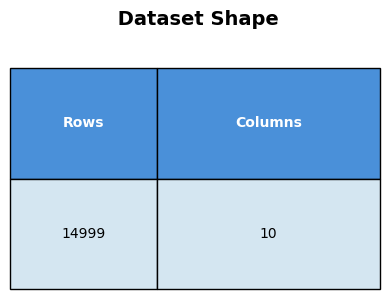




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



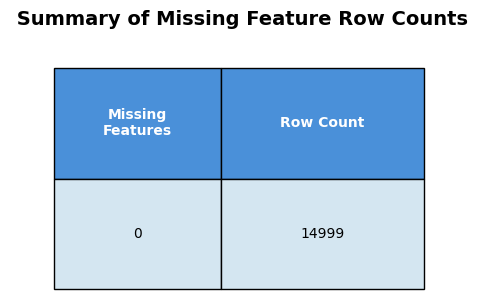

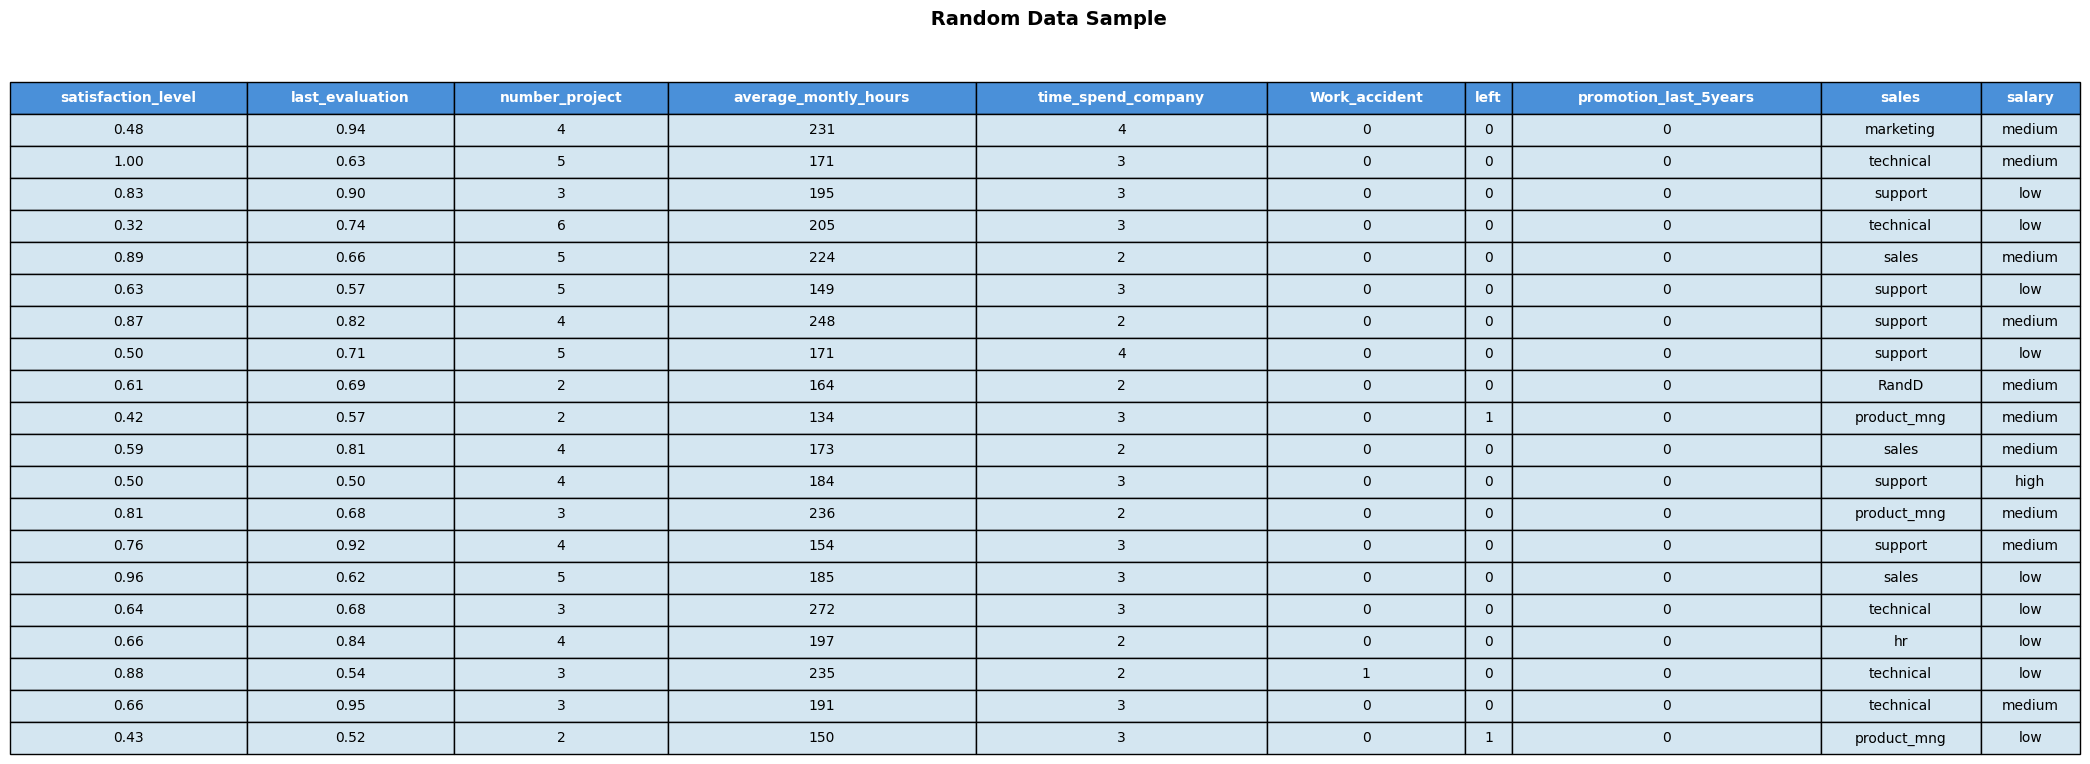

In [4]:
# print out the dataframes stats
print(data_set_name)
PrintDataFrameStatistics(df_employeeTurnOver)

### **Initial EDA Analysis** ###
    - Movie Data - 14999 rows of data, 10 features (columns)
    - No rows of missing or (nan) data in either dataset
    - Need to leading/following trim() categorical feature columns

## **2. Initial Data Wrangling** ## 

### **Missing Values and Imputation** ###
Not required

##### **Trim Categorical Features** #####

In [5]:
obj_cols = df_employeeTurnOver.select_dtypes(include='object').columns
df_employeeTurnOver[obj_cols] = df_employeeTurnOver[obj_cols].apply(lambda col: col.str.strip())

#### **Feature Column Renaming** ####
    - Rename 'sales' to 'department' 
      'sales' column is in correctly named. It really should be called department as the column includes such
      values as: sales, accounting, hr,.. 
    - Rename average_montly_hours (sp mistake)

In [6]:
df_employeeTurnOver.rename(columns={'sales': 'department'}, inplace=True)
df_employeeTurnOver.rename(columns={'average_montly_hours': 'average_monthly_hours'}, inplace=True)

# Save dataframe so get_dummies() technique can be applied later
df_employeeTurnOverSaved = df_employeeTurnOver.copy (deep=True)

Unique number_project Values


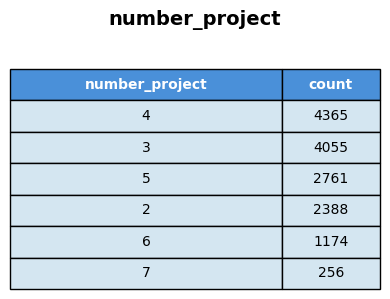



Unique average_monthly_hours Values


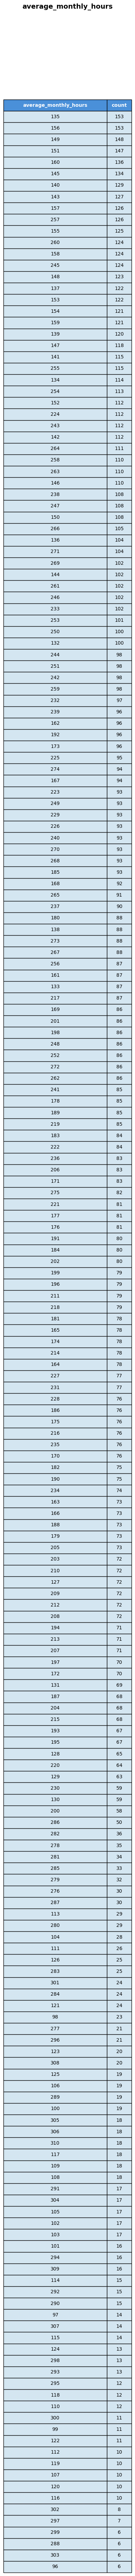



Unique time_spend_company Values


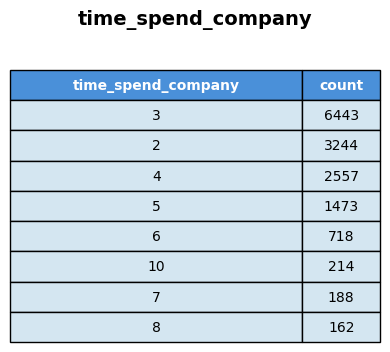



Unique Work_accident Values


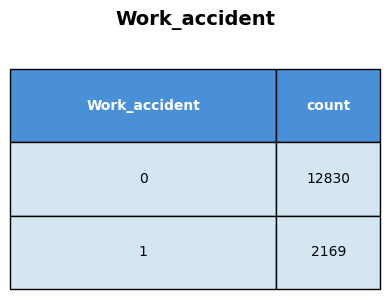



Unique left Values


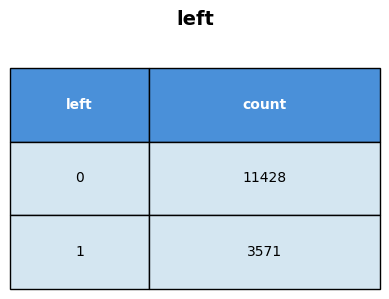



Unique promotion_last_5years Values


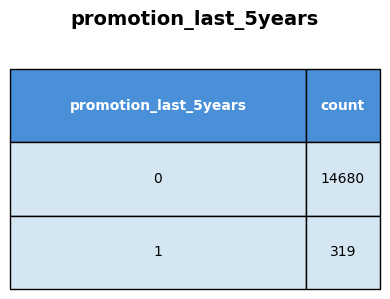



Unique department Values


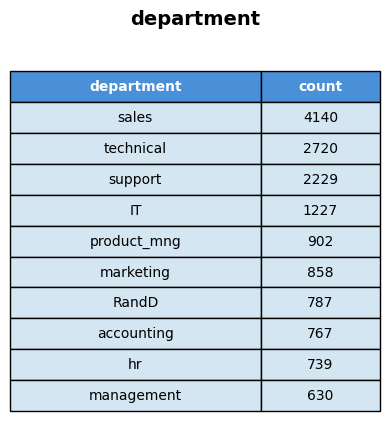



Unique salary Values


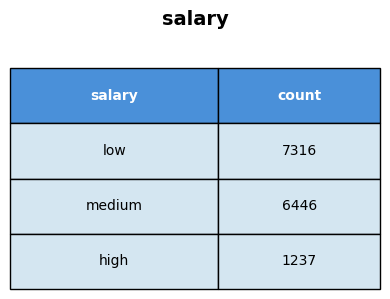

In [7]:
def DisplayUniqueValues(feature_name):
    print(f'Unique {feature_name} Values')
    df_departments = df_employeeTurnOver[feature_name].value_counts().reset_index()
    DisplayTable(df_departments, table_title=feature_name)    

feature_names = ['number_project', 'average_monthly_hours',
                'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'department', 'salary']

list(map(DisplayUniqueValues, feature_names))
print()


#### **Label Encoding - One-Hot Encode Categorical Features** ####

***********************************
Description Stats
***********************************

                   Feature    count unique    top  freq        mean  \
0       satisfaction_level  14999.0    NaN    NaN   NaN    0.612834   
1          last_evaluation  14999.0    NaN    NaN   NaN    0.716102   
2           number_project  14999.0    NaN    NaN   NaN    3.803054   
3    average_monthly_hours  14999.0    NaN    NaN   NaN  201.050337   
4       time_spend_company  14999.0    NaN    NaN   NaN    3.498233   
5            Work_accident  14999.0    NaN    NaN   NaN     0.14461   
6                     left  14999.0    NaN    NaN   NaN    0.238083   
7    promotion_last_5years  14999.0    NaN    NaN   NaN    0.021268   
8               department    14999     10  sales  4140         NaN   
9                   salary    14999      3    low  7316         NaN   
10           department_IT  14999.0    NaN    NaN   NaN    0.081805   
11        department_RandD  14999.0    NaN    NaN   NaN  

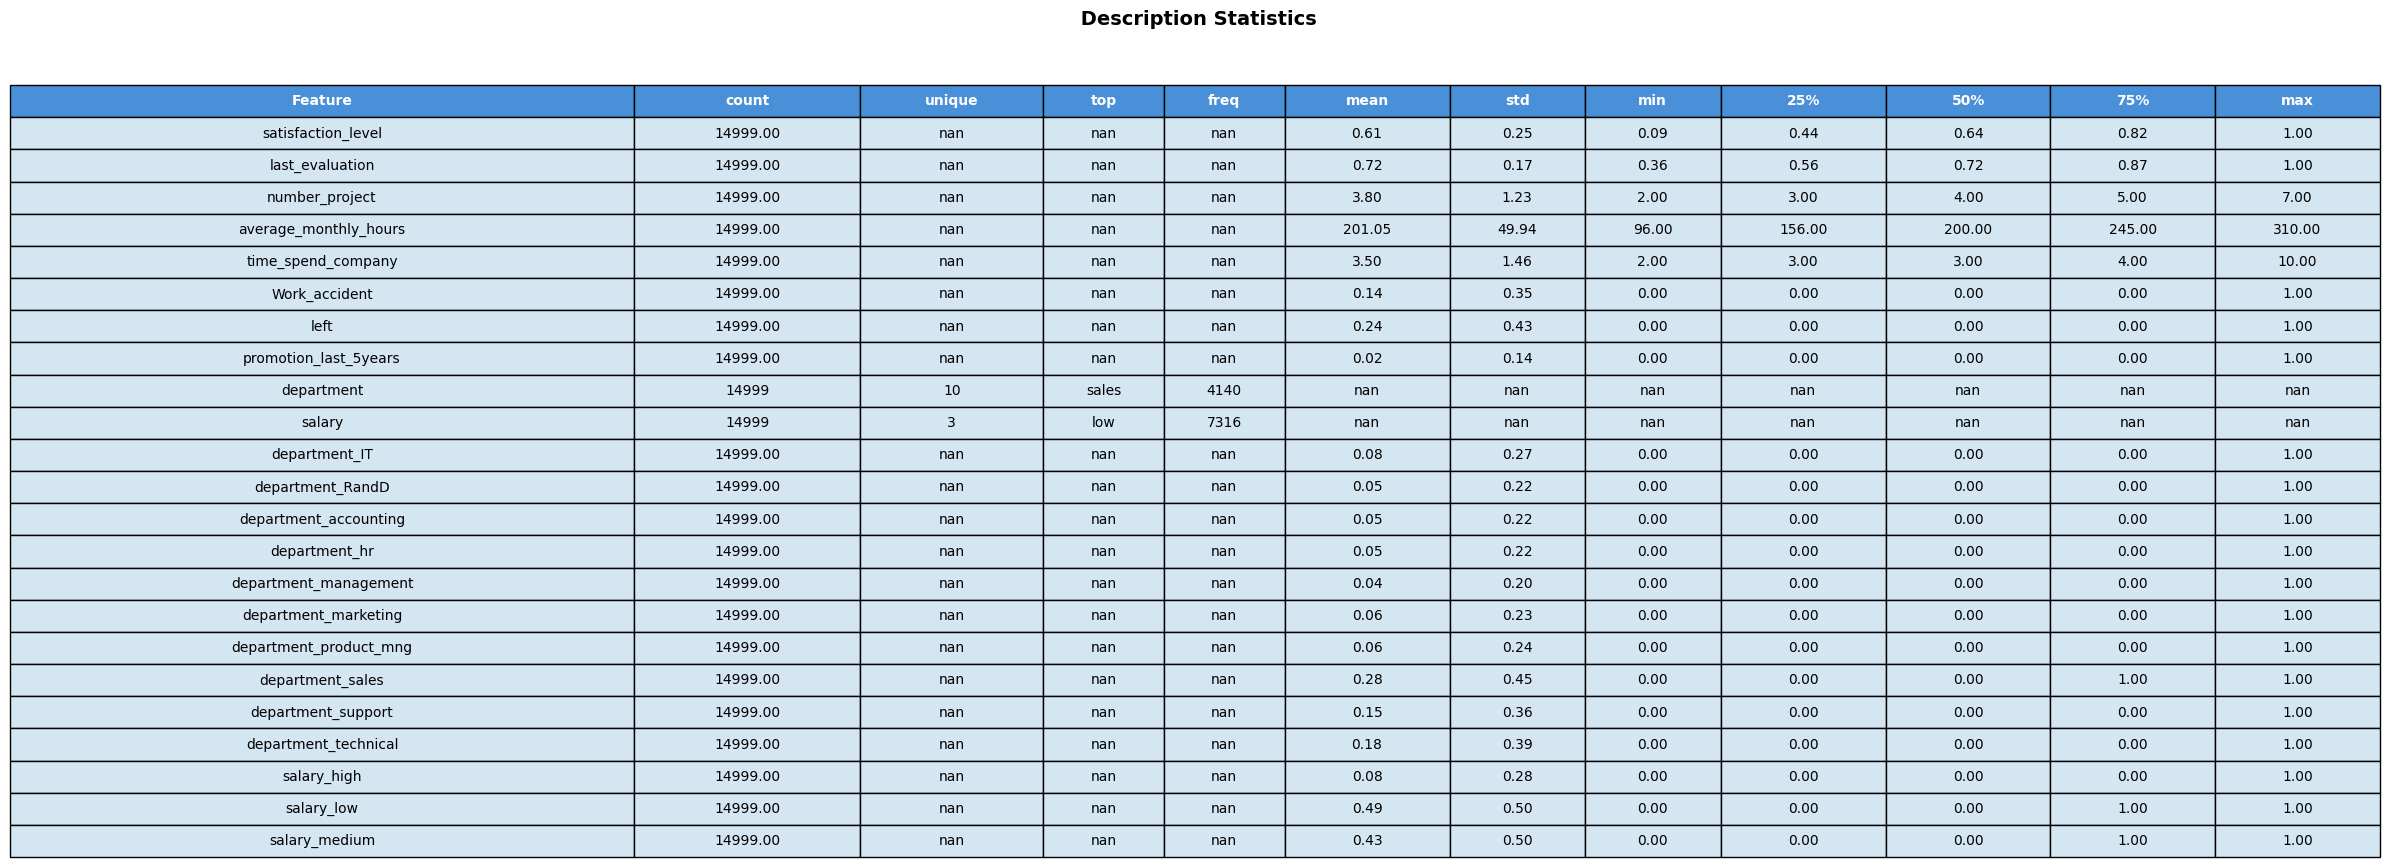

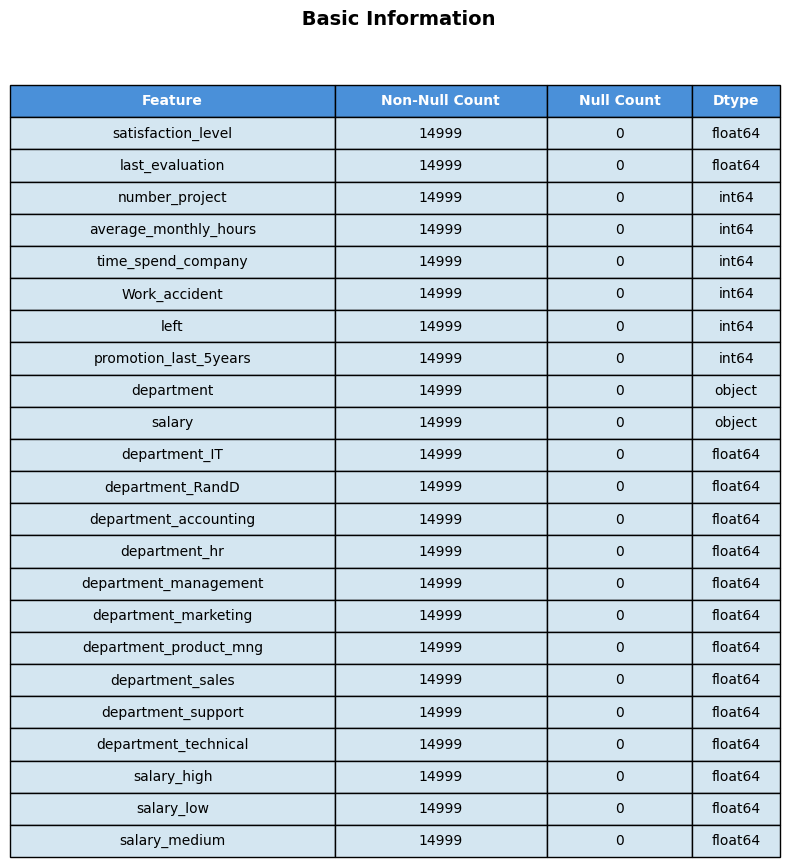

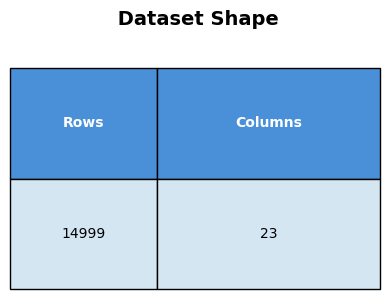




No data to display:  Missing Categorical (String) Data

No data to display:  Missing Numeric Data



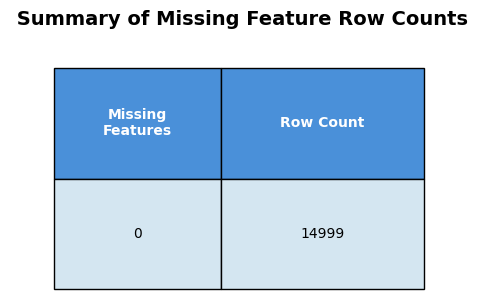

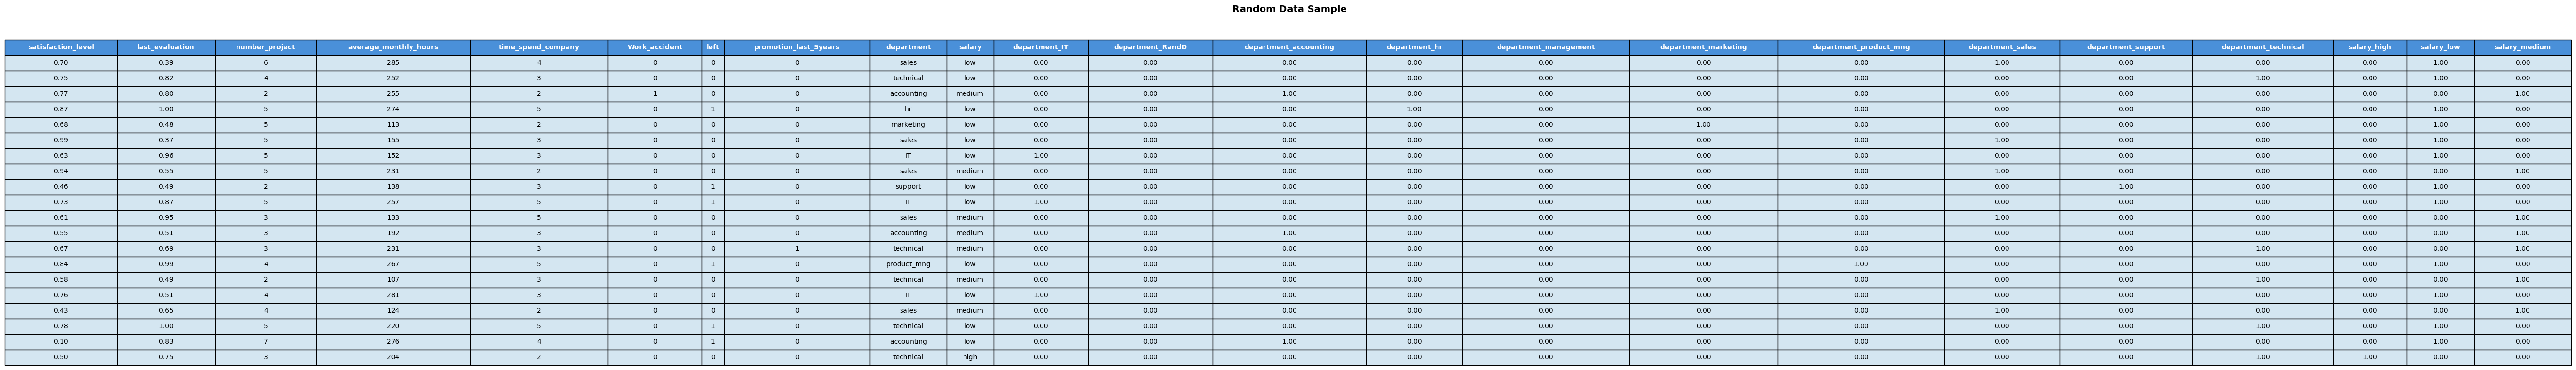

In [8]:
# Use the nominal categorical variable (department)
# Apply one-hot encoding
#encoder = OneHotEncoder(sparse_output=False, drop='first')

# Don't drop 'first' for now as we want to see all our columns and the distribution
# Drop these later depanding on the model we use to reduce/avoid multicolinearity
encoder = OneHotEncoder(sparse_output=False)

# Convert Department
onehot_array = encoder.fit_transform(df_employeeTurnOver[['department']])

# Create dataframe with proper column names
df_onehot = pd.DataFrame(
    onehot_array,
    columns=encoder.get_feature_names_out(['department']),
    index=df_employeeTurnOver.index
)

# Join back to original and drop original column
df_employeeTurnOver = pd.concat([df_employeeTurnOver, df_onehot], axis=1)

# Convert Salary
onehot_array = encoder.fit_transform(df_employeeTurnOver[['salary']])

# Create dataframe with proper column names
df_onehot = pd.DataFrame(
    onehot_array,
    columns=encoder.get_feature_names_out(['salary']),
    index=df_employeeTurnOver.index
)

# Join back to original and drop original column
df_employeeTurnOver = pd.concat([df_employeeTurnOver, df_onehot], axis=1)

PrintDataFrameStatistics(df_employeeTurnOver)

### **Data Type Conversion** ###
    - For OS memory performance and model efficiency, convert to more efficient data types.

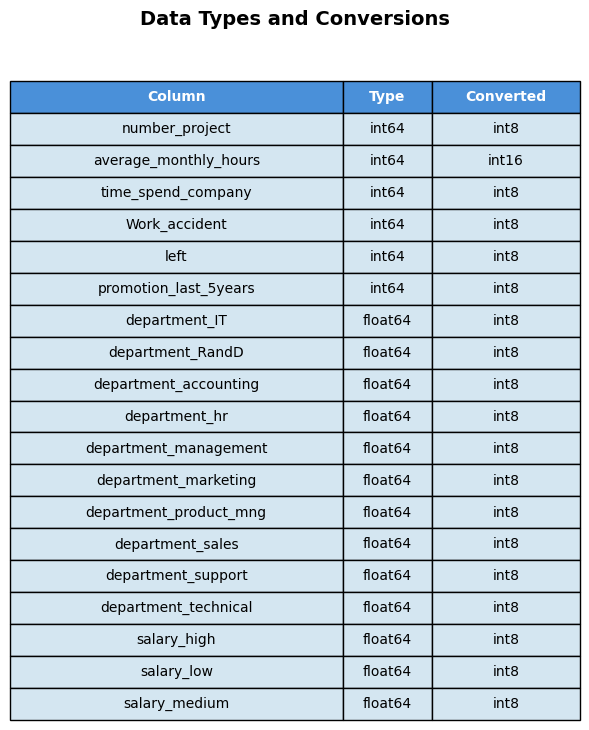




Converted Data Columns


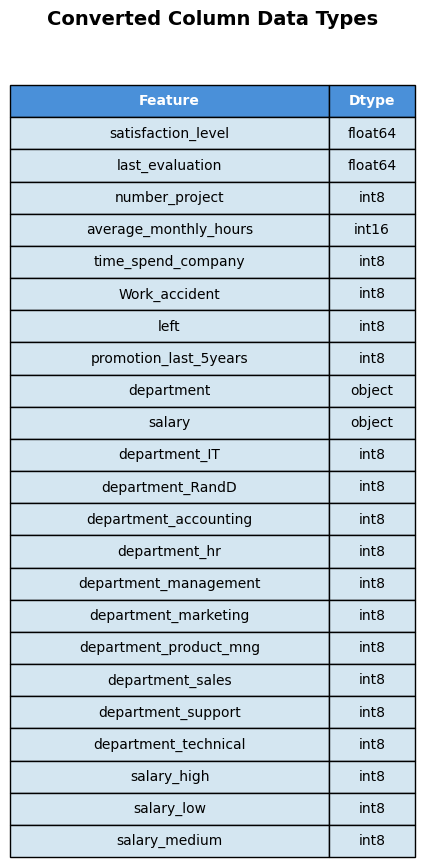

In [9]:
# Features, Types and Data Type Conversion Targets..
df_types = pd.DataFrame({
                    'Column': [
                        'number_project', 'average_monthly_hours', 'time_spend_company', 'Work_accident', 'left',
                        'promotion_last_5years', 'department_IT', 'department_RandD', 'department_accounting',
                        'department_hr', 'department_management', 'department_marketing', 'department_product_mng',
                        'department_sales', 'department_support', 'department_technical', 'salary_high', 'salary_low',
                        'salary_medium',
                    ],
                    'Type': [
                        'int64', 'int64', 'int64', 'int64', 'int64', 'int64', 'float64', 
                        'float64', 'float64', 'float64', 'float64', 'float64', 'float64', 
                        'float64', 'float64', 'float64', 'float64', 'float64', 'float64',
                    ],
                    'Converted': [
                        'int8', 'int16', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 
                        'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8', 'int8'
                    ]
                })


#print(df_types)

DisplayTable(df_types, table_title='Data Types and Conversions', max_cell_length=60)
print()

def PerformDataConversion(df_target, remove_class_prefix=False, display_output=False):

    # Convert Int64 to Int16 
    int_columns = ['average_monthly_hours']
    df_target[int_columns] = df_target[int_columns].astype('int16')

    # Convert Int64 to Int8 
    int_columns = ['number_project', 'time_spend_company', 'Work_accident', 'left',
                    'promotion_last_5years', 'department_IT', 'department_RandD', 'department_accounting',
                    'department_hr', 'department_management', 'department_marketing', 'department_product_mng',
                    'department_sales', 'department_support', 'department_technical', 'salary_high', 'salary_low',
                    'salary_medium' 
                ]
    
    if remove_class_prefix == True:
        int_columns = [col.replace('department_', '').replace('salary_', '') for col in int_columns]

    df_target[int_columns] = df_target[int_columns].astype('int8')

    if display_output == True:
        print('Converted Data Columns')

        df_info = pd.DataFrame({
                                'Feature': df_target.columns,
                                'Dtype': df_target.dtypes.values
                                }).reset_index(drop=True)
        DisplayTable(df_info, 'Converted Column Data Types')
    
    return df_target

df_Merged = PerformDataConversion(df_employeeTurnOver, display_output=True)

## <u>**3. Detailed Exploratory Data Analysis**</u> ##
##### **Display Count Plots** #####
    Display some initial Bar/Count Plots to give us an insight into any trends such as:
        - What days, months, years ratings were likely to occur
        - What movie release years the data set is focusing on 

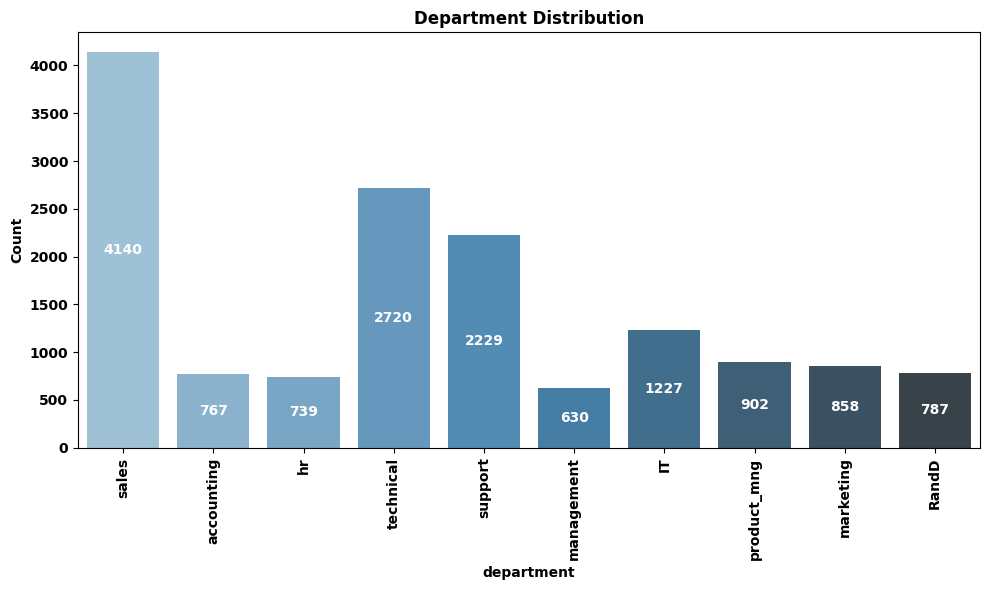

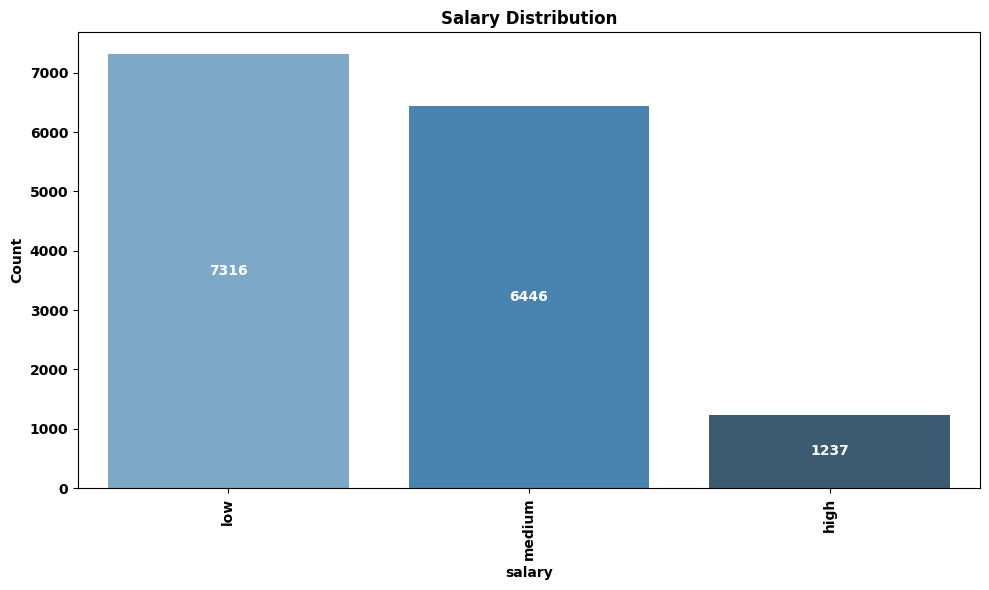

In [11]:
def DisplayBarPlot(df_Target, x_axis, y_axis, plot_title):
    # Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=x_axis, 
                     y=y_axis, 
                     data=df_Target, 
                     hue=x_axis, 
                     palette='Blues_d', 
                     legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel('Genre', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt='%.0f')

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, hue_value=None, plot_labels=None, displayLabels=True):

    if hue_value is not None:
        hue = hue_value
    else:
        hue = x_axis

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=hue, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    if plot_labels is not None:
        plt.legend(title=hue, labels=plot_labels)

    plt.tight_layout()
    plt.show()


# Department Count Plot
departmentOrder = df_employeeTurnOver['department'].unique().tolist()
DisplayCountPlot(df_employeeTurnOver, 'department', departmentOrder, 'Department Distribution', (10,6))

departmentOrder = df_employeeTurnOver['salary'].unique().tolist()
DisplayCountPlot(df_employeeTurnOver, 'salary', departmentOrder, 'Salary Distribution', (10,6))

##### **Examine Numerical Feature Distributions** #####

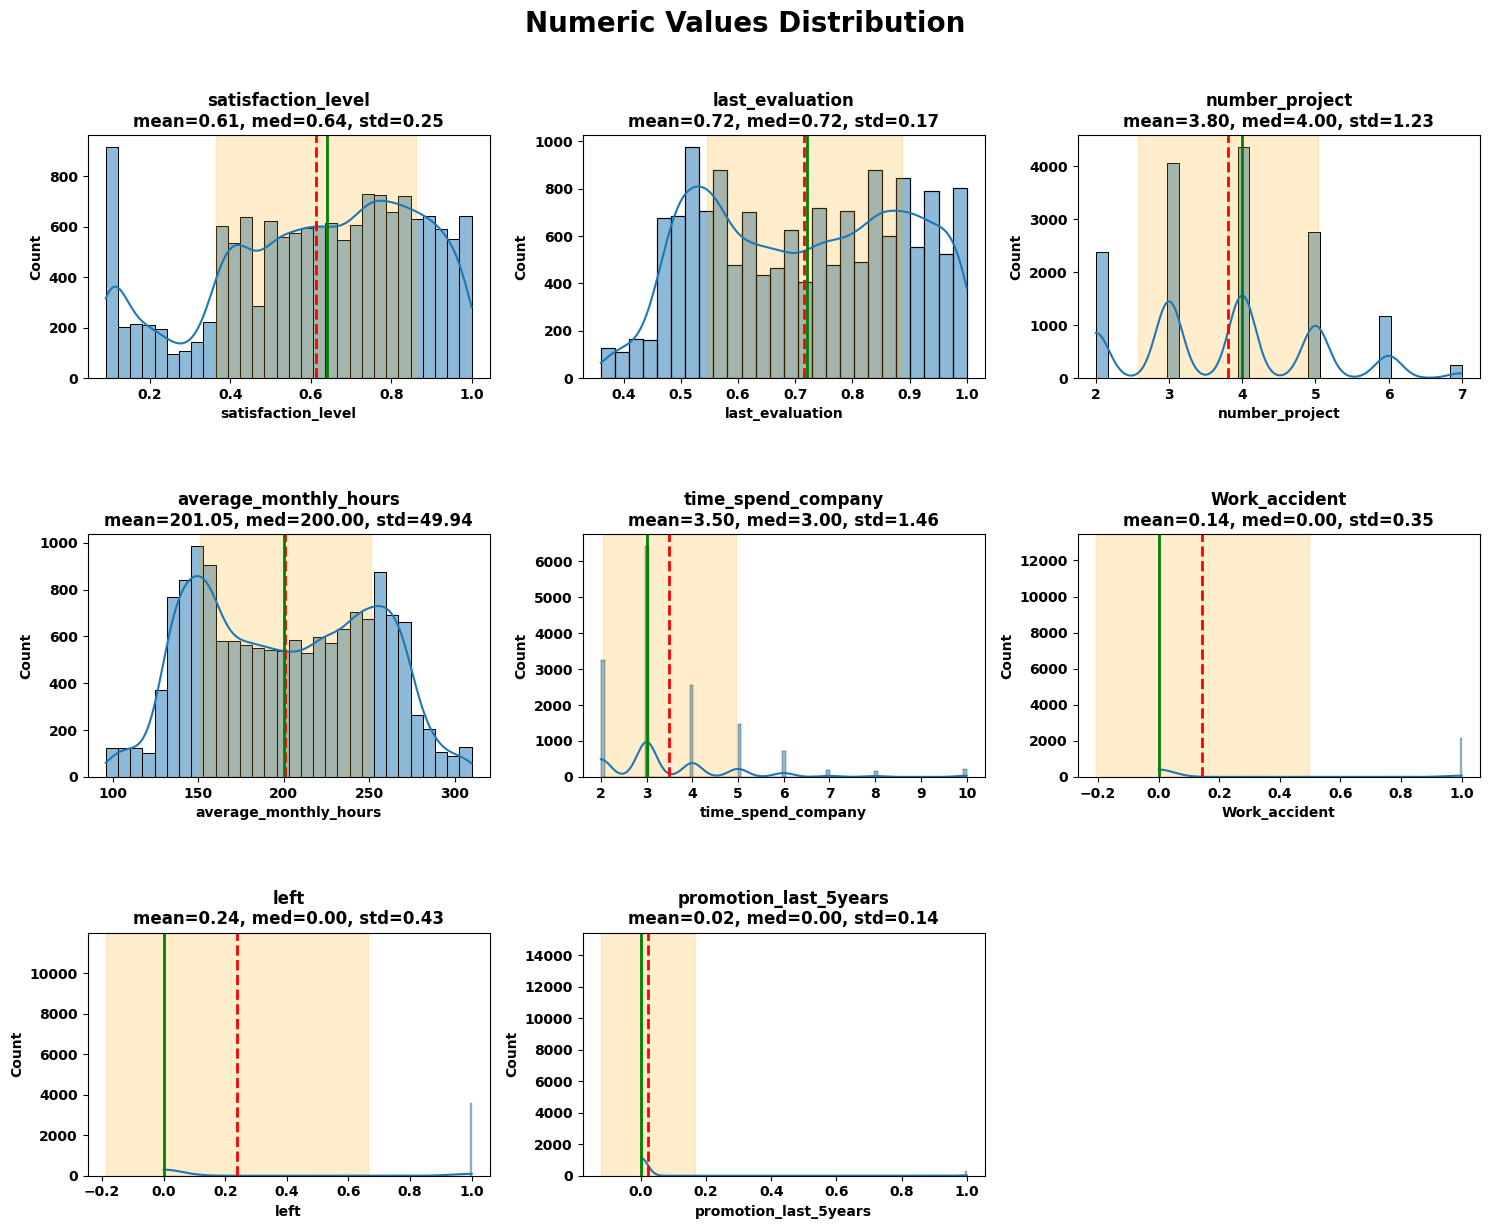

In [12]:
def DisplayNumericFeatureHistograms(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        data = df_target[col]

        if display_statistics == True:

            min_val = data.min()
            max_val = data.max()
            range_val = data.max() - data.min()
            mean_val = data.mean()
            median_val = data.median()
            mode_val = data.mode().tolist()
            std_val = data.std()
            quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
            skew_val = data.skew()
            kurtosis_val = data.kurtosis()

            stats = {
                'Feature': col,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std': std_val,
                'Range': range_val,
                'Quantile': quantile_val,
                'Skew': skew_val,
                'Kurtosis': kurtosis_val
            }            

            statistics.append(stats)

            # print(f'Min Value: {min_val:.3f}')
            # print(f'Max Value: {max_val:.3f}')
            # print(f'Mean Value: {mean_val:.3f}')
            # print(f'Median Value: {median_val:.3f}')
            # print(f'Mode Value: {mode_val}')
            # print(f'Standard Deviation: {std_val:.3f}')
            # print(f'Range Value = {range_val:.3f}')
            # print(f'Quantile Value = {quantile_val}')
            # print(f'Skew Value: {skew_val:.3f}')
            # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

            axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

            # Vertical lines for mean and median, shaded std
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
            axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

        else:
            axes[i].set_title(f'{col}', fontweight='bold')
        
        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(title, y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

feature_columns = [
                    'satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours',
                    'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years'
                ]
DisplayNumericFeatureHistograms(df_employeeTurnOver, 
                                feature_columns=feature_columns,
                                plot_title = 'Numeric Values Distribution', 
                                display_statistics=True)

##### **Numerical Feature Distribution Observations** #####
    - satisfaction_level is normalish
    - last_evaluation is normalish/bimodal with 2 definite peaks
    - number_project looks multi modal but actually, when you look close it has a normal distribution
    - average_monthly_hours is normalish/bimodal with 2 definite peaks
    - The following features look like they have a definite right skew:
        - time_spend_company
        - Work_accident
        - left
        - promotion_last_5years

##### **Correlation Matrix of Numerical Features** #####

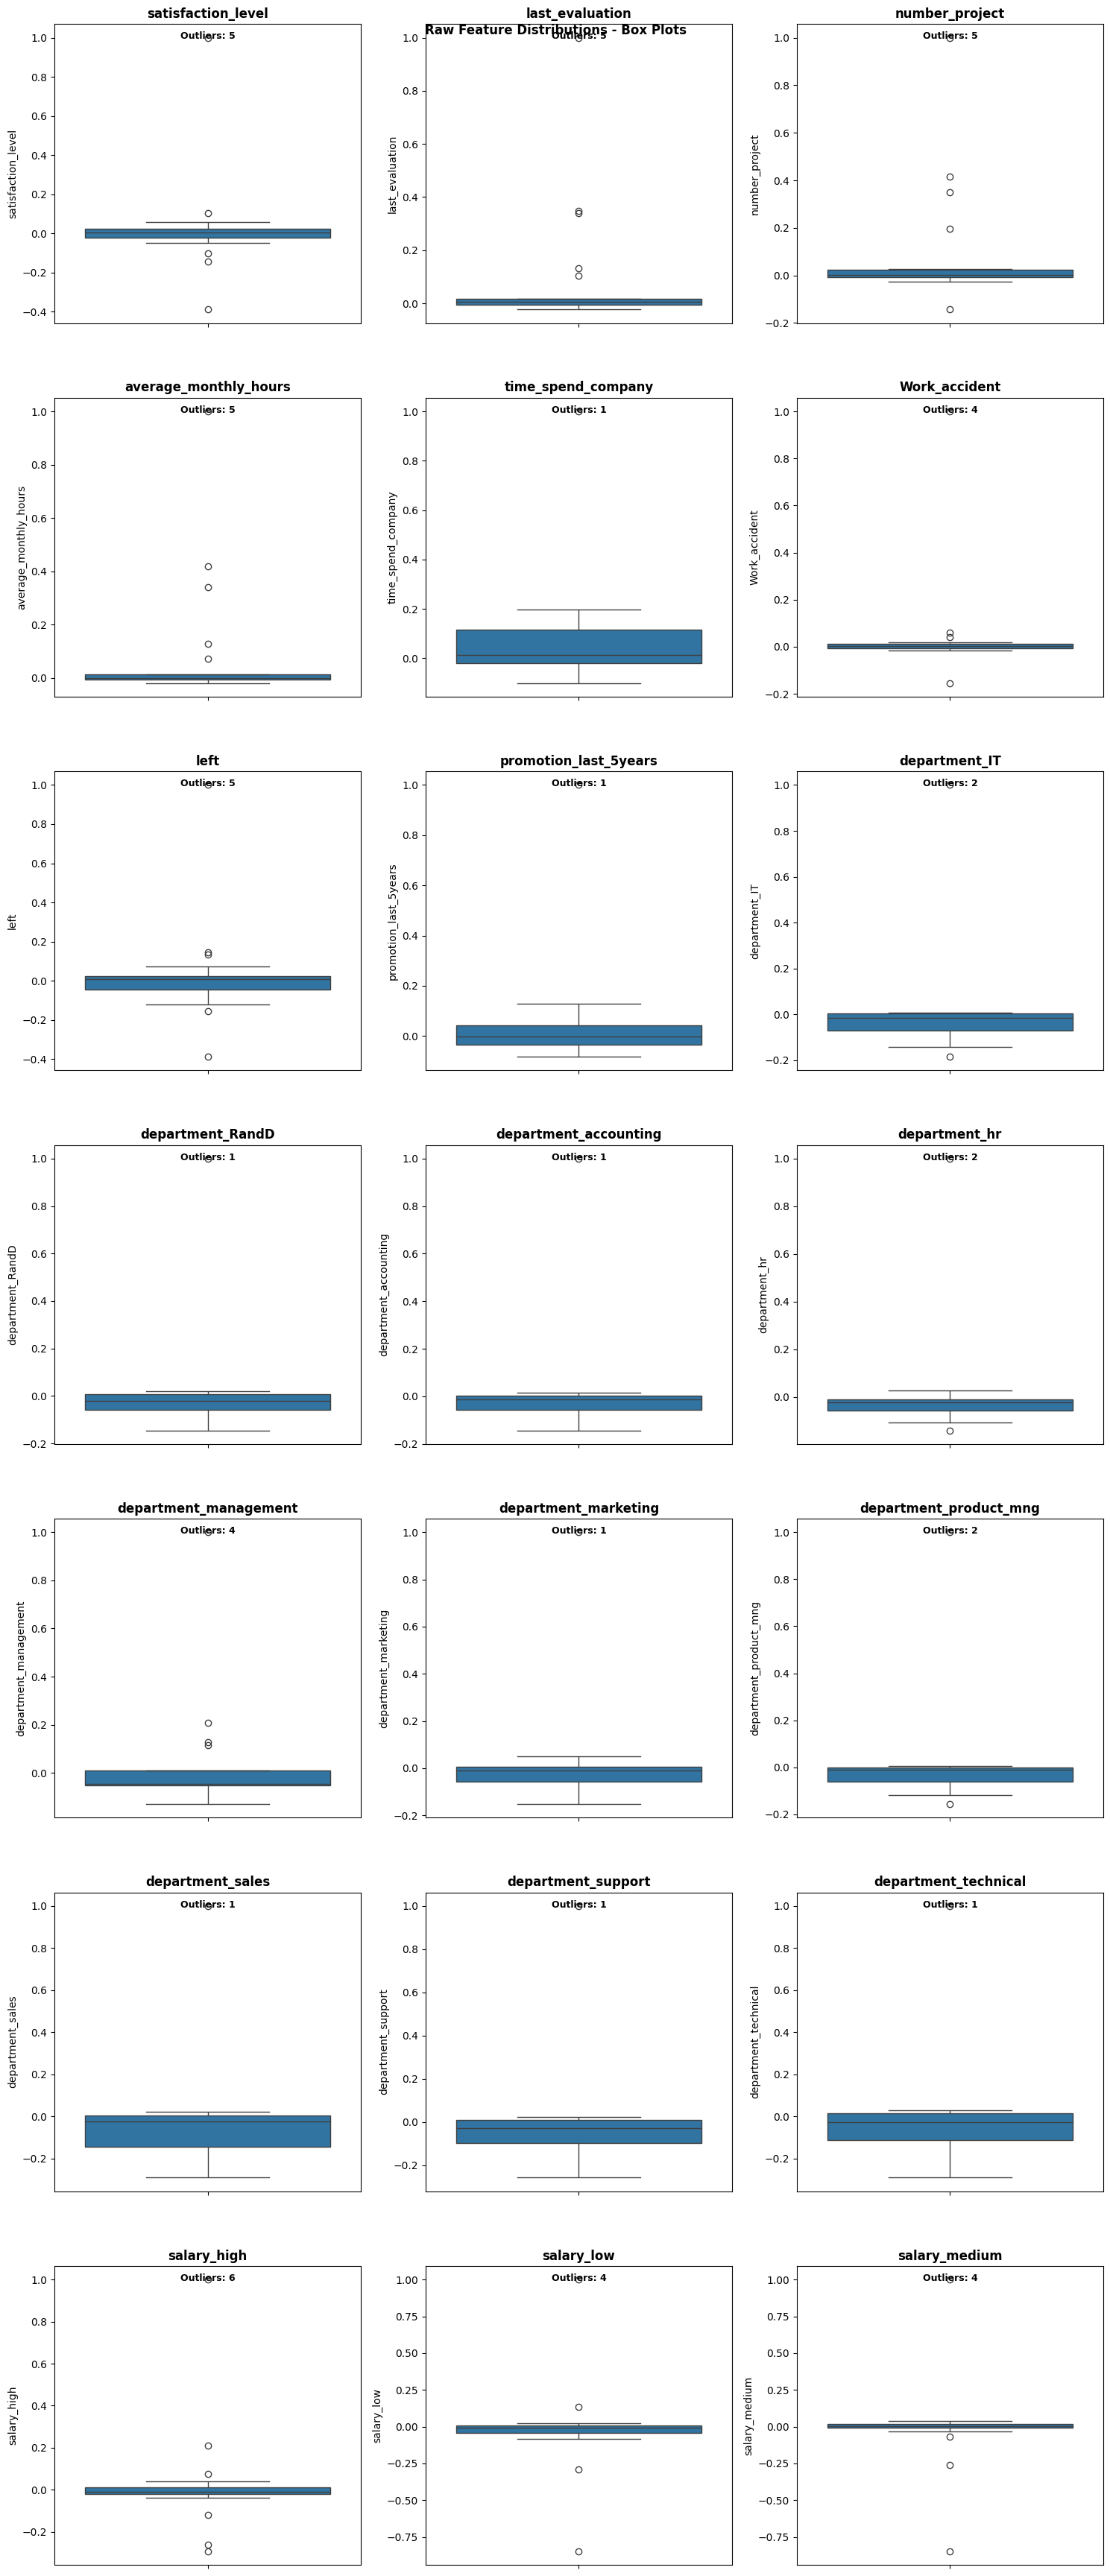

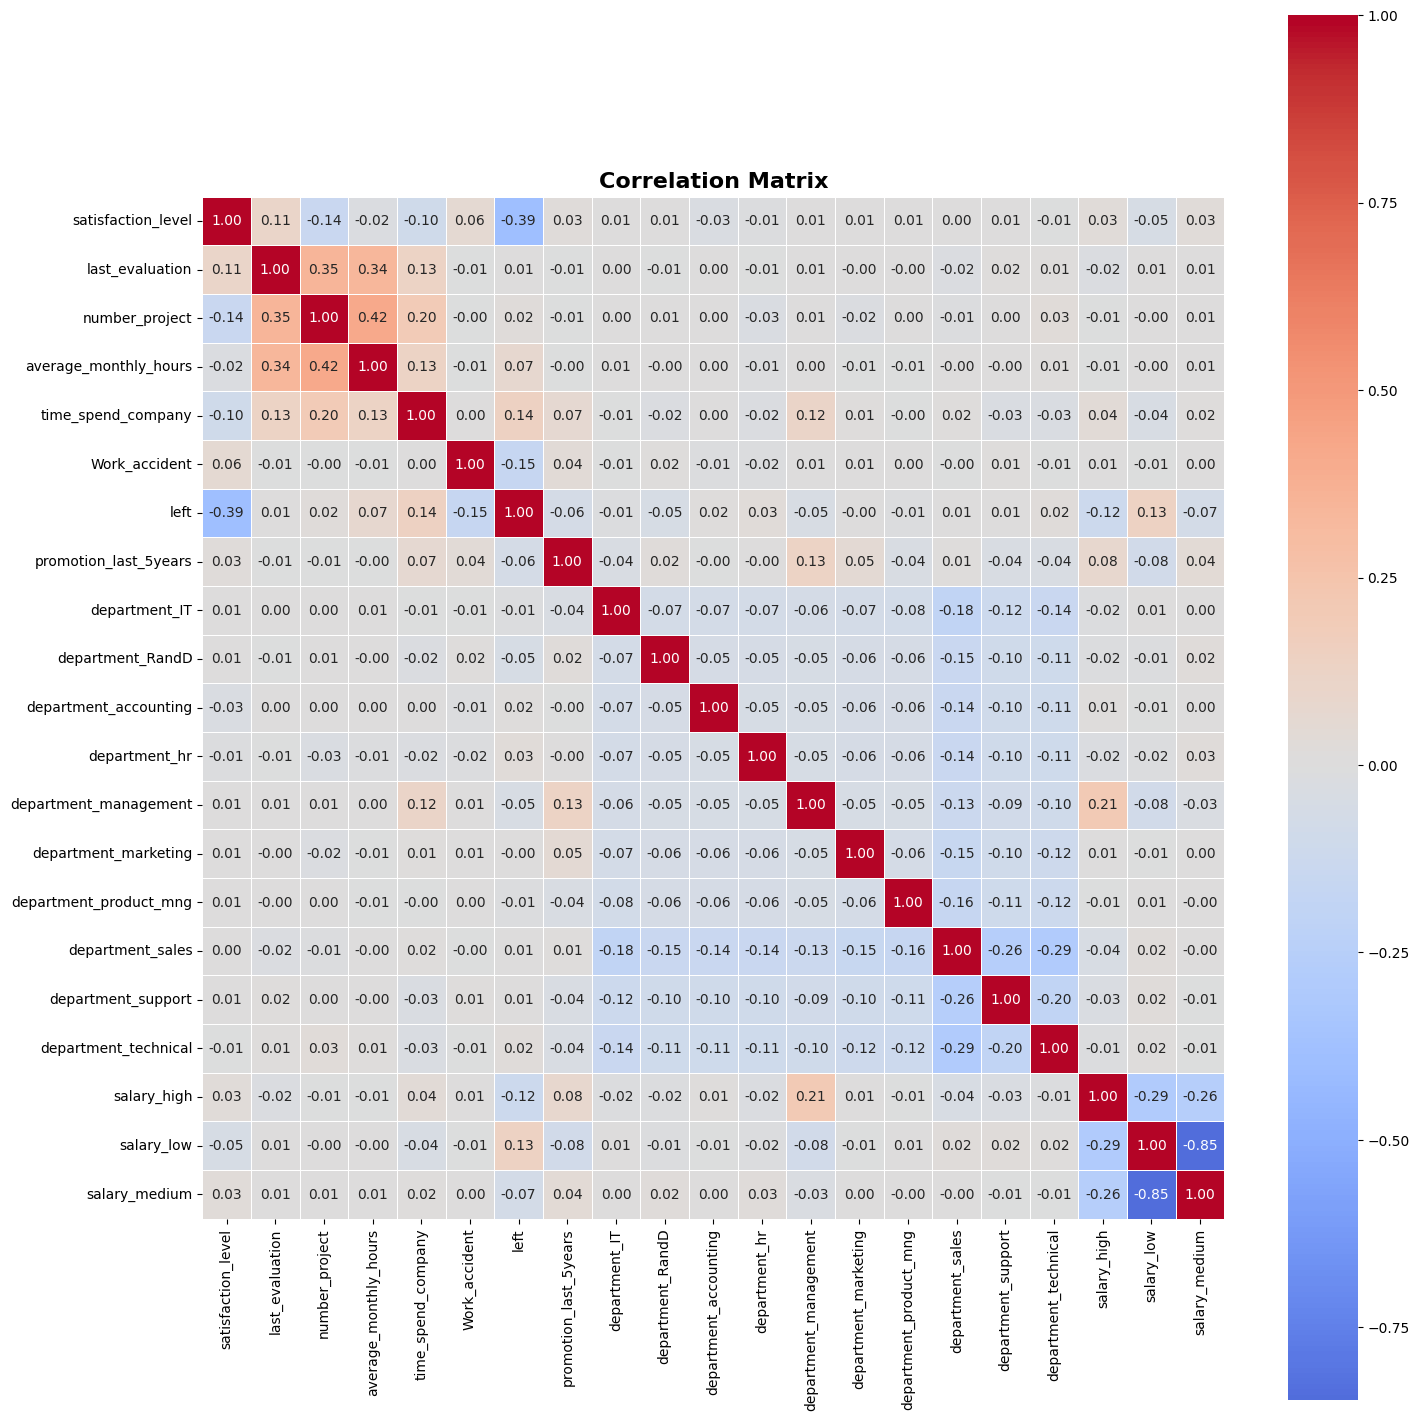

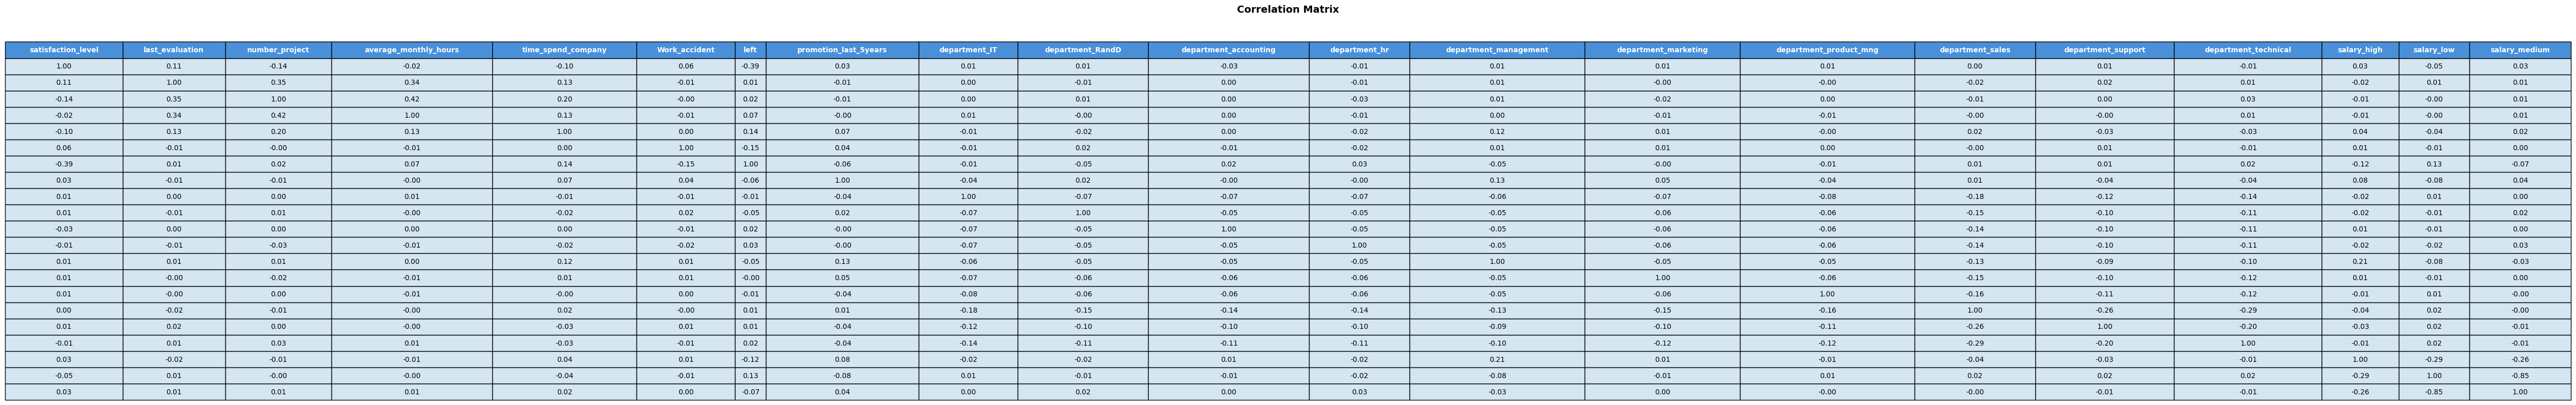



The following table displays the lowest correlations in the dataset, having abs(value) of close to 0.00


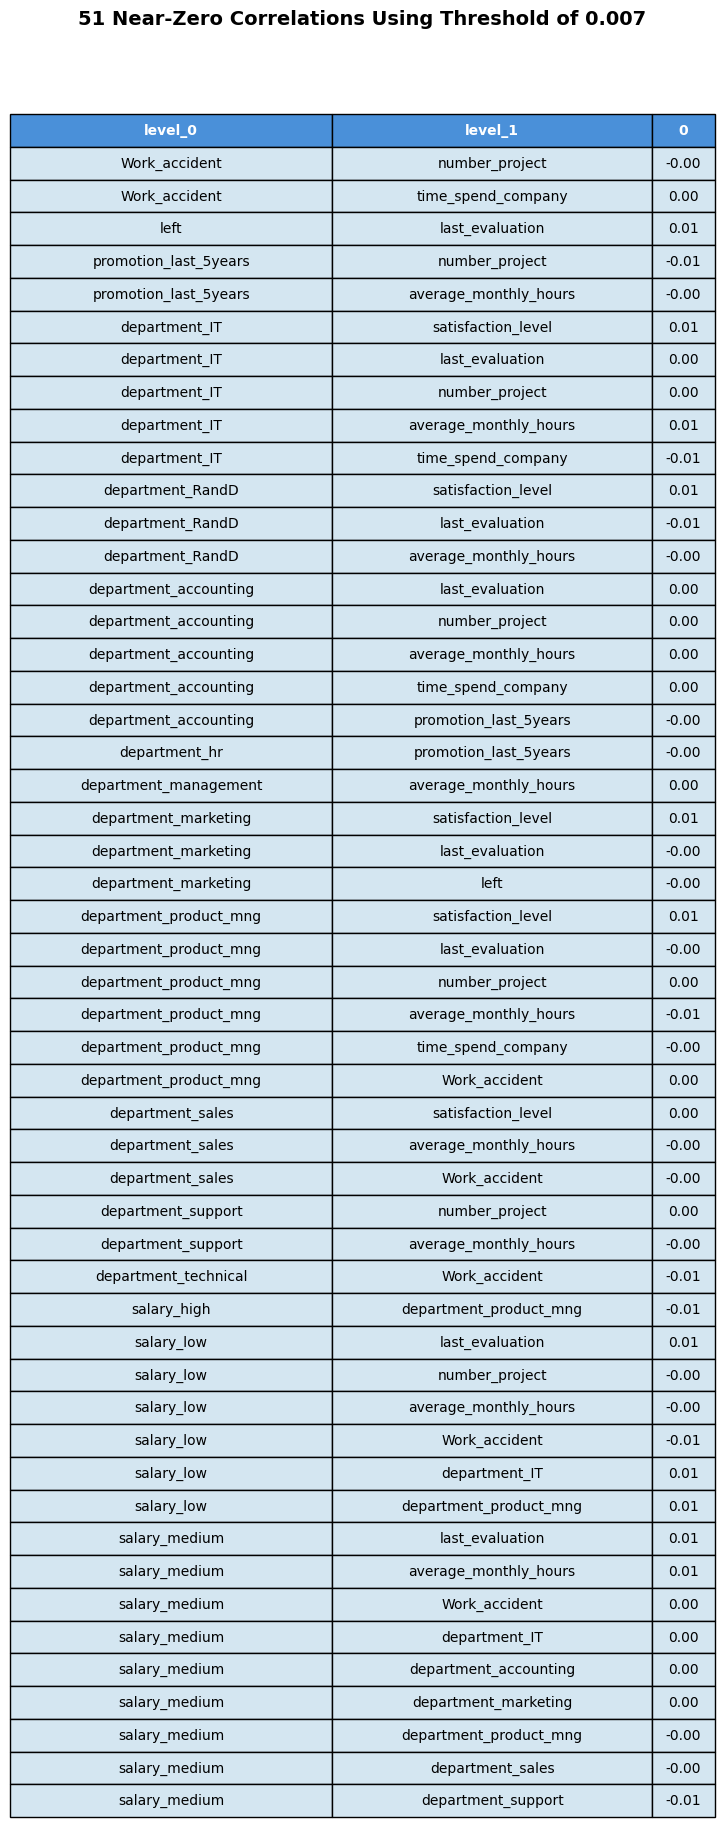

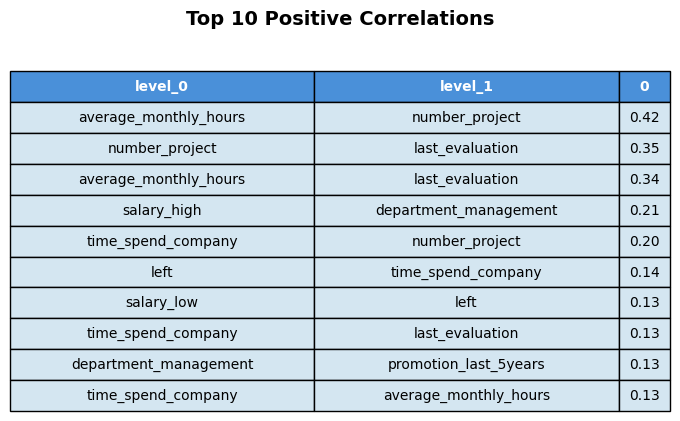

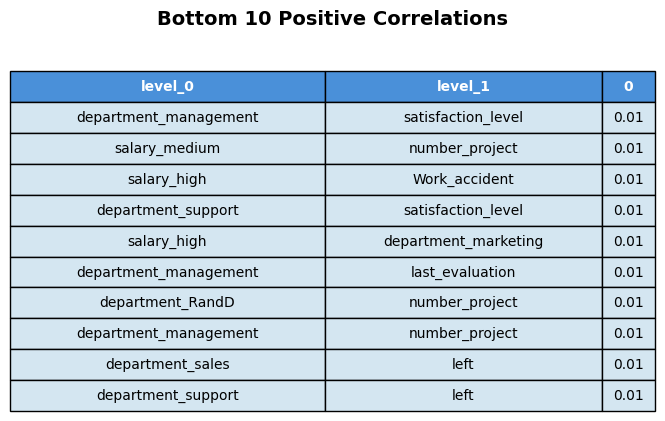



                 level_0               level_1         0
0  department_management    satisfaction_level  0.007172
1          salary_medium        number_project  0.007377
2            salary_high         Work_accident  0.009040
3     department_support    satisfaction_level  0.009185
4            salary_high  department_marketing  0.009642
5  department_management       last_evaluation  0.009662
6       department_RandD        number_project  0.009703
7  department_management        number_project  0.009728
8       department_sales                  left  0.009923
9     department_support                  left  0.010700



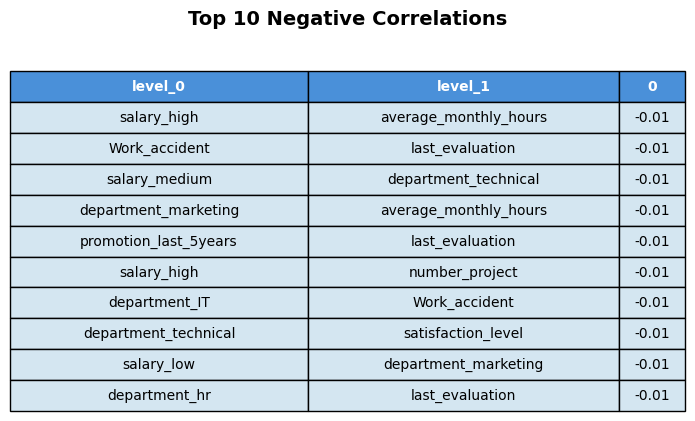

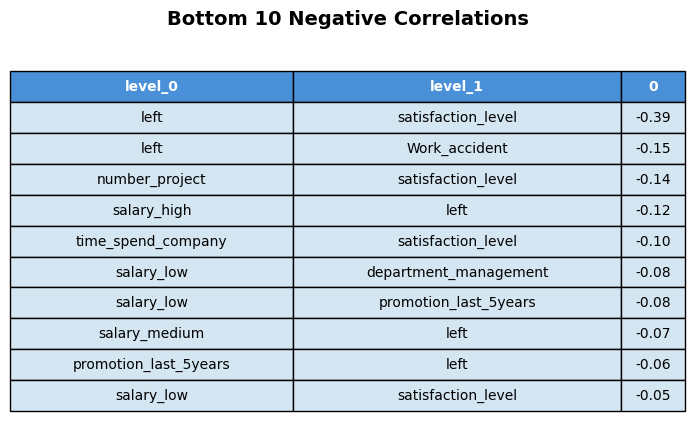

In [13]:
#
# Features to Bike Rentals Correlations
#
def PlotBoxPlotsToViewDistributions(df_target):

    columns = df_target.select_dtypes(include='number').columns.tolist()
    n_cols = len(columns)

    fig, axes = plt.subplots(nrows=(n_cols + 2) // 3, ncols=3, figsize=(15, 5 * ((n_cols + 2) // 3)))
    axes = axes.flatten()

    plt.suptitle('Raw Feature Distributions - Box Plots', fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.90])  # Leave space at top

    #Iterate over each numeric column and plot a historgram
    for i, col in enumerate(columns):
        sns.boxplot(data=df_target, y=col, ax=axes[i])    
        axes[i].set_title(col, fontweight='bold')

        # Optional: Add count of outliers
        Q1 = df_target[col].quantile(0.25)
        Q3 = df_target[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = len(df_target[(df_target[col] < lower) | 
                                            (df_target[col] > upper)])
        axes[i].text(0.5, 0.95, f'Outliers: {outlier_count}', 
                    transform=axes[i].transAxes, ha='center', fontsize=9, fontweight='bold')

    # Make plots more readable and add space
    plt.tight_layout(h_pad=5)
    plt.show() 


def DisplayCorrelationMatrixPlots(df_correlationInfo):
        
        # print(type(df_correlationInfo))
        # print(df_correlationInfo)

        # Create heatmap
        plt.figure(figsize=(15, 15))
        sns.heatmap(df_correlationInfo, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                    square=True, linewidths=0.5)
        plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

        print()
        print()    


# Check if two features are from the same one-hot encoded group
def SameOneHotEncodedGroup(feat1, feat2):
    
    prefixes = ['department_', 'salary_']

    for prefix in prefixes:
        if feat1.startswith(prefix) and feat2.startswith(prefix):
            return True
        
    return False        
        

def DisplayFeatureCorrelationInfo(df_target, display_correlation_matrix=True, display_box_plots=True, display_table=True):
    
    df_correlationMatrix = df_target.corr(numeric_only=True)
    #print(f'Correlation Matrix Type: {type(df_correlationInfo)}')
    # print(df_correlationInfo)

    if display_box_plots == True:
       PlotBoxPlotsToViewDistributions(df_correlationMatrix)

    if display_correlation_matrix == True:
        DisplayCorrelationMatrixPlots(df_correlationMatrix)

    if display_table == True:
         DisplayTable(df_correlationMatrix, table_title='Correlation Matrix')

    # Get top 10 for each category:
    #
    # 1) Highest positive covariance
    # 2) Lowest positive covariance
    # 3) Lowest negative covariance
    # 4) Highest negative covariance

    # Unstack to series for sorting
    # To prevent from duplicate (feature order swapped) entries, focus on upper triangle of matrix
    # Numpy has function to do this.
    # Get upper triangle only (no duplicates, no diagonal)
    mask = np.triu(np.ones(df_correlationMatrix.shape), k=1).astype(bool)
    correlationSeries = df_correlationMatrix.where(mask).unstack().dropna()

    # Filter out same-group pairs
    # (Definitely needed help figgering this one out....)
    correlationSeries = correlationSeries[
                                            ~correlationSeries.index.map(lambda x: SameOneHotEncodedGroup(x[0], x[1]))
                                        ]

    # Drop self referencing (val == 1)
    correlationSeries = correlationSeries[correlationSeries != 1.0]

    # No absolute 0 in float/double values ..., have to use threshold
    threshold = 0.007
    noCorrelationSeries = correlationSeries[abs(correlationSeries) < threshold]
    df_zeroCorrelations = noCorrelationSeries.reset_index()
    print('The following table displays the lowest correlations in the dataset, having abs(value) of close to 0.00')
    DisplayTable(df_zeroCorrelations, table_title=f'{len(df_zeroCorrelations)} Near-Zero Correlations Using Threshold of {threshold}')

    # Filter out near-zero values before getting top/bottom
    correlationSeries = correlationSeries[abs(correlationSeries) >= threshold]

    # Positive Correlations
    positiveCorrelations = correlationSeries[correlationSeries > 0]
    df_topPositiveCorrelations = positiveCorrelations.sort_values(ascending=False).head(10).reset_index()
    df_bottomPositiveCorrelations = positiveCorrelations.sort_values(ascending=True).head(10).reset_index()

    # Negative Correlations
    negativeCorrelations = correlationSeries[correlationSeries < 0]
    df_topNegativeCorrelations = negativeCorrelations.sort_values(ascending=False).head(10).reset_index()
    df_bottomNegativeCorrelations = negativeCorrelations.sort_values(ascending=True).head(10).reset_index()

    # Display results in pretty table
    DisplayTable(df_topPositiveCorrelations, table_title='Top 10 Positive Correlations')
    #print(df_topPositiveCorrelations)
    print()

    DisplayTable(df_bottomPositiveCorrelations, table_title='Bottom 10 Positive Correlations')
    print(df_bottomPositiveCorrelations)
    print()

    DisplayTable(df_topNegativeCorrelations, table_title='Top 10 Negative Correlations')
    #print(df_topNegativeCorrelations)
    print()

    DisplayTable(df_bottomNegativeCorrelations, table_title='Bottom 10 Negative Correlations')
    #print(df_bottomNegativeCorrelations)
    print()
    

DisplayFeatureCorrelationInfo(df_employeeTurnOver.drop(['department', 'salary'], axis=1))

#### **Observations from Correlation Matrix** ####
These observations exclude those correlations closest to 0.00 via threshold filtering.</br>
These 102 relationships have already been indentified has having the least/weakest association.</br>
</br>
It's difficult to interpret the correlations with the results including the noise of the one-hot-encoded </br>
categorical values being compared against each other (department_#### vs department_####, salary_#### vs salary_####). </br>
This distorts the results. In order to remove this noise, these relationships had to be removed from our series comparisons </br>

##### **Noteable Outliers** #####
1. satisfaction_level
	- The volume of lower plotted outliers indicates there is a group of employees with notably low satisfaction levels</br>
2. last_evaluation
	- Most evaluations are clusterd with similar scores, but ther are a number that have unusually high evaluations.</br>
3. number_project
	- Most employees are clustered around the same number of projects. There are few outliers with a low project number.</br>
	  There are also several that have a high number of projects </br>
4. average_monthly_hours
	- Most employees work around the same number of hours a month, but there are small group that work a high number of hours.</br>
5. Work_accident
	- Most people had no work related accidents (minority class/class imbalance).</br> 
	  A small number of people (outliers) reported an actual accident.</br>	
<br>

##### **Top Positive Covariances** #####
1. average_monthly_hours vs number_project (0.417211)
	- Makes sense. More projects, more hours.</br>
2. number_project vs last_evaluation (0.349333)
	- Strong correlation between the number of projects being worked on and strength of evaluation</br>
3. average_monthly_hours vs last_evaluation (0.339742)
	- Same for this, evaluation results tied to number of hours worked.</br>
4. salary_high vs department_management (0.209077)
	- Moderate correlation between high salaries and management positions</br>
5. time_spend_company vs number_project (0.196786)
	- Moderate between number of projects and years at a company</br>
6. left vs time_spend_company (0.144822)
	- Moderate correlation between number of years at a company and leaving</br>
7. salary_low vs left (0.134722)
	- Moderate for low salary and leaving company.</br>
8. time_spend_company vs last_evaluation (0.131591)
	- Moderate between years at company and value of last evaluation</br>
9. department_management vs promotion_last_5years (0.128087)
	- Low-moderate correlation between management position and frequency of promotions</br>
10. time_spend_company vs average_monthly_hours (0.12775)
	- Low-moderate for years at company vs monthly hours</br>

##### **Bottom Positive Covariances** #####
1. department_management vs satisfaction_level (0.007172)
	- Being a manager doesn't affect satisfaction level</br>
2. salary_medium vs number_project (0.007377)
	- Salary not related to number of projects being worked on. (You're giving them free hours!!)</br>
3. department_sales vs left (0.009923)
	- Being in sales doesn't make you more likely to leave</br>

##### **Top Negative Covariances** #####
1. salary_high vs average_monthly_hours (-0.007101)
	- Salary not related to hours worked.</br>
2. Work_accident vs last_evaluation (-0.007104)
	- Accidents don't affect reviews</br>
3. salary_medium vs department_technical (-0.007673)
	- Salary level not correlated with technical positions</br>
##### **Bottom Negative Covariances** #####
1. left vs satisfaction_level (-0.388375)
	- Job satisfaction affects wheter people will leave.</br>
2. left vs Work_accident (-0.154622)
	- If someone's had a work accident, they're moderately more likely to leave.</br>
3. number_project vs satisfaction_level (-0.142970)
	- Employees with less projects are more satisfied. More projects, stress increases, unhappier employee.</br>
4. salary_high vs left (-0.120929)
	- Higher salaried employees are moderately more likely to see employment elsewhere.</br>

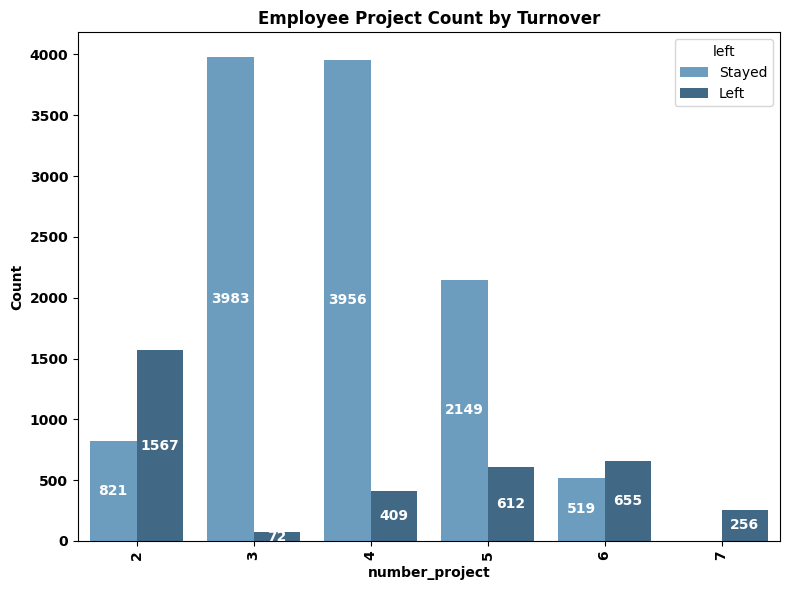

In [14]:
# Department Count Plot
projectNumberOrder = np.sort(df_employeeTurnOver['number_project'].unique().tolist())
DisplayCountPlot(df_employeeTurnOver, 
                 'number_project', 
                 projectNumberOrder, 
                 'Employee Project Count by Turnover', 
                 (8,6), 
                 hue_value='left',
                 plot_labels=['Stayed','Left'])

##### **Employee Project Count Turnover Analysis** #####
People working on 3 to 4 projects are likely to stay (that's the sweet spot)</br>
</br>
After that, as then number of projects increase, so does the likelyhood that they will leave.</br>
This is probably due to any of the following reasons (increased stress, not being able to focus and get better</br>
on specific tasks/skillsets, not feeling appreciated for efforts?)</br>
Once someone is assigned 7 projects, they are out the door</br>
</br>
People assigned less than 3 projects are highly likely to leave (not feeling valued/respected/appreciated).</br>

## <u>**4. Cluster Analysis - Employee Turnover**</u> ##
Choose the following columns: </br>
        - satisfaction_level</br>
        - last_evaluation</br>
        - left</br>
</br>

For completeness and to satisfy my curiousity, I examined KMeans, Hierarchical and DBScan Clustering</br>
and plotted results fir KMeans and Hierarchical.

##### **Cluster Utility Functions** #####

In [15]:
def PlotClusterResults(k_range, wcss, sil_scores, cluster_type):

    #
    # Plot the Elbow Method
    #

    # I need a 1X2 plot to display 2 plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes = axes.flatten()

    axes[0].plot(k_range, wcss, 'b-', marker='o')

    kl = KneeLocator(k_range, wcss, curve='convex', direction='decreasing')
    print(f"Optimal k for KMeans Clustering: {kl.elbow}")
    axes[0].axvline(x=kl.elbow, color='r', linestyle='--', label=f'Elbow at k={kl.elbow}')

    axes[0].set_title('The Elbow Method')
    axes[0].set_xlabel('Number of clusters')
    axes[0].set_ylabel('WCSS')
    axes[0].legend()
    
    #
    # Plot Silhouette Analysis
    #
    best_k = k_range[np.argmax(sil_scores)]
    best_score = max(sil_scores)

    axes[1].plot(k_range, sil_scores, 'b-', marker='o')
    axes[1].axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')
    axes[1].axhline(y=best_score, color='gray', linestyle=':', alpha=0.5)

    # Annotate each point
    for k, score in zip(k_range, sil_scores):
        axes[1].annotate(f'{score:.3f}', (k, score), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

    axes[1].set_xlabel('Number of clusters')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Analysis')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Clustering Analysis for {cluster_type}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout()
    plt.show()
    print()
    print()

##### **KMeans Clustering** #####

Optimal k for KMeans Clustering: 6


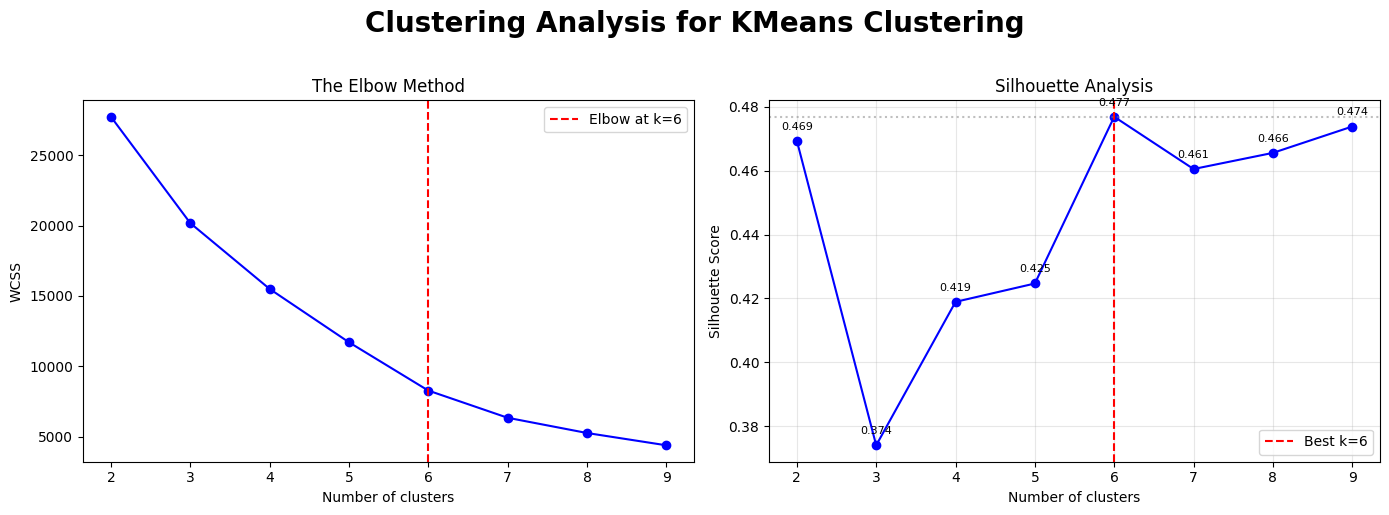

In [16]:
# KMeans Cluster Analysis

df_forScaling = df_employeeTurnOver[['satisfaction_level','last_evaluation','left']]
#print(df_forScaling.shape)

kmeans_wcss = []
kmeans_sil_scores = []
k_range = range(2, 10) 

# Scale data before applying kmeans
scaler = StandardScaler()

# Create a dataframe from scale (which returns npdarray)
df_employeeTurnOverScaled = pd.DataFrame(
                                        scaler.fit_transform(df_forScaling),
                                        columns=df_forScaling.columns,
                                        index=df_forScaling.index
                                    )

#
# KMeans Clustering
# 

# Iterate through K-Means cluster with number of clusters 2-10
for i in k_range:
    model = KMeans(n_clusters = i, n_init=10, init = 'k-means++', random_state = 315)
    model.fit(df_employeeTurnOverScaled)
    kmeans_wcss.append(model.inertia_)

    labels = model.predict(df_employeeTurnOverScaled)
    kmeans_sil_scores.append(silhouette_score(df_employeeTurnOverScaled, labels))

PlotClusterResults(k_range, kmeans_wcss, kmeans_sil_scores, 'KMeans Clustering')



##### **KMeans Results and Analysis** #####
Elbow method indicates 6 clusters is optimal</br>
Silhouette scores indicate that 6 clusters is optimal</br>
Both scoring methods agree on using 6 clusters.</br>

##### **Hierarchical (Agglomerative) Clustering** #####

Optimal k for KMeans Clustering: 5


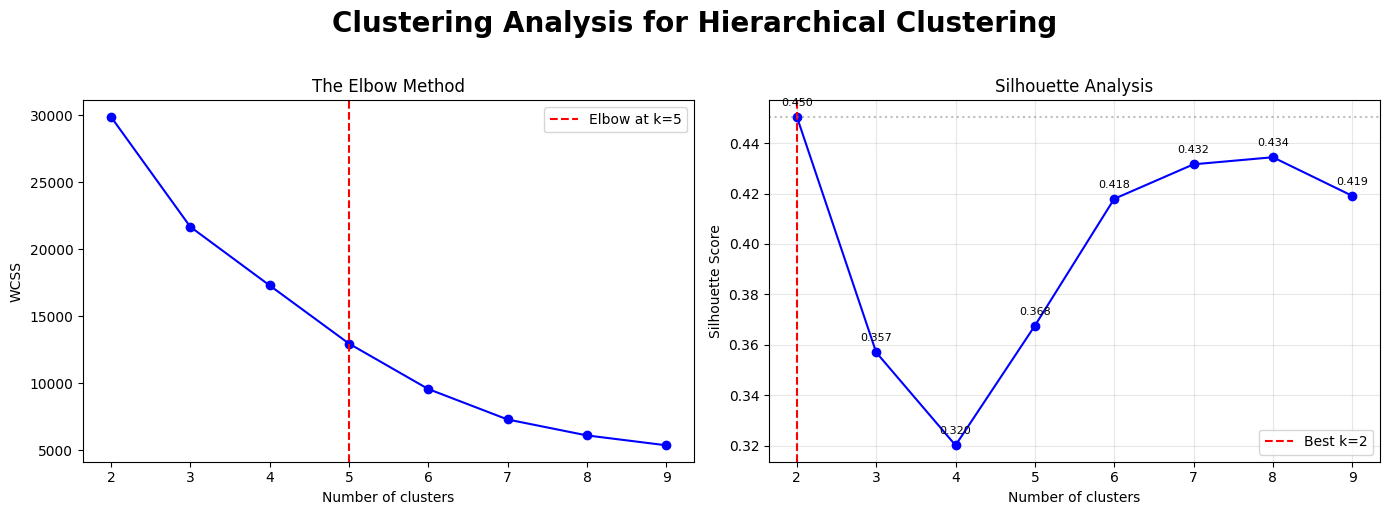

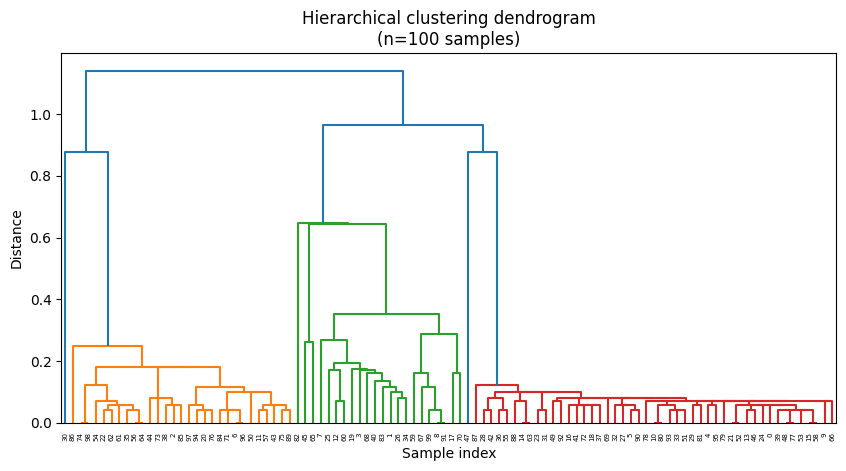

In [17]:
#
# Hierarchical (Agglomerative) Clustering
#
agglo_sil_scores = []
agglo_wcss = []

# Iterate through K-Means cluster with number of clusters 2-10
for i in k_range:
    # Fit hierarchical clustering
    model = AgglomerativeClustering(n_clusters=i)
    labels = model.fit_predict(df_employeeTurnOverScaled)

    # Calculate WCSS manually
    wcss = 0
    for cluster in range(i):
        labels = model.fit_predict(df_employeeTurnOverScaled)
        cluster_points = df_employeeTurnOverScaled[labels == cluster]
        centroid = cluster_points.mean(axis=0)
        wcss += ((cluster_points - centroid) ** 2).sum().sum()

    agglo_wcss.append(wcss)
    agglo_sil_scores.append(silhouette_score(df_employeeTurnOverScaled, labels))

PlotClusterResults(k_range, agglo_wcss, agglo_sil_scores, 'Hierarchical Clustering')

# Create dendrogram
linkage_matrix = linkage(df_employeeTurnOverScaled.iloc[:100])

plt.figure(figsize=(10, 4.8))
dendrogram(linkage_matrix)
plt.title('Hierarchical clustering dendrogram\n(n=100 samples)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()


##### **Hierarchical Clustering Results and Analysis** #####
Processing for this analysis takes a long time (~5 min), </br>
Probably best to do this against a smaller subset of the dataframe. </br>
</br>
Elbow method indicates 5 clusters is optimal</br>
Silhouette scores indicate that 2 clusters is optimal</br>

##### **DBScan Clustering** #####

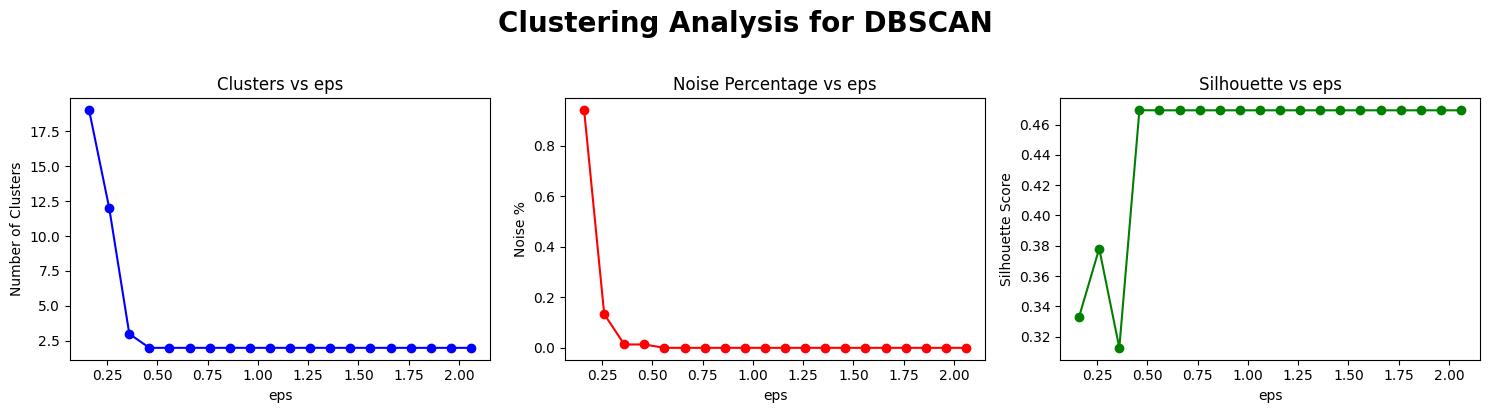

In [18]:
#
# DBSCAN Clustering
#

# Parameter ranges to test
eps_range = np.arange(0.16, 2.1, 0.1)  # Adjust based on your data
min_samples = 5  # Can also loop over this

dbscan_results = []

for eps in eps_range:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(df_employeeTurnOverScaled)
    
    # Count clusters (excluding noise labeled as -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    # Silhouette score (only if more than 1 cluster and not all noise)
    if n_clusters > 1 and n_noise < len(labels):
        # Exclude noise points for silhouette
        mask = labels != -1
        sil_score = silhouette_score(df_employeeTurnOverScaled[mask], labels[mask])
    else:
        sil_score = -1  # Invalid
    
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': n_noise / len(labels) * 100,
        'silhouette': sil_score
    })

df_dbscan_results = pd.DataFrame(dbscan_results)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Number of clusters
axes[0].plot(df_dbscan_results['eps'], df_dbscan_results['n_clusters'], 'b-', marker='o')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('Number of Clusters')
axes[0].set_title('Clusters vs eps')

# Plot 2: Noise percentage
axes[1].plot(df_dbscan_results['eps'], df_dbscan_results['noise_pct'], 'r-', marker='o')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Noise %')
axes[1].set_title('Noise Percentage vs eps')

# Plot 3: Silhouette score
valid = df_dbscan_results[df_dbscan_results['silhouette'] > -1]
axes[2].plot(valid['eps'], valid['silhouette'], 'g-', marker='o')
axes[2].set_xlabel('eps')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette vs eps')

plt.suptitle(f'Clustering Analysis for DBSCAN', y=1.02, fontsize=20, fontweight='bold')
plt.subplots_adjust(top=0.92)  

plt.tight_layout()
plt.show()    



##### **DBSCAN Results and Analysis** #####
**Clusters vs eps:** eps flattens at 2 clusters when eps ≥ 0.5 </br>
**Noise % vs eps:** Nose drops at eps=0.3, flattens near 0% at eps ≥ 0.5 </br>
**Silhouette vs eps:** Best score (~0.47) at eps ≥ 0.5</br>
**Conclusion:** Use 2 clusters, but for completeness we'll examine results for 2, 3 and 4 clusters </br>
</br>

##### **Visualize Clusters for K-Means** #####
6 Clusters seems like a large number. </br>
It could be difficult to interpret/delineate the results. </br>
What would the results look like with 4, 5 or 6 clusters?</br>
Let's see.

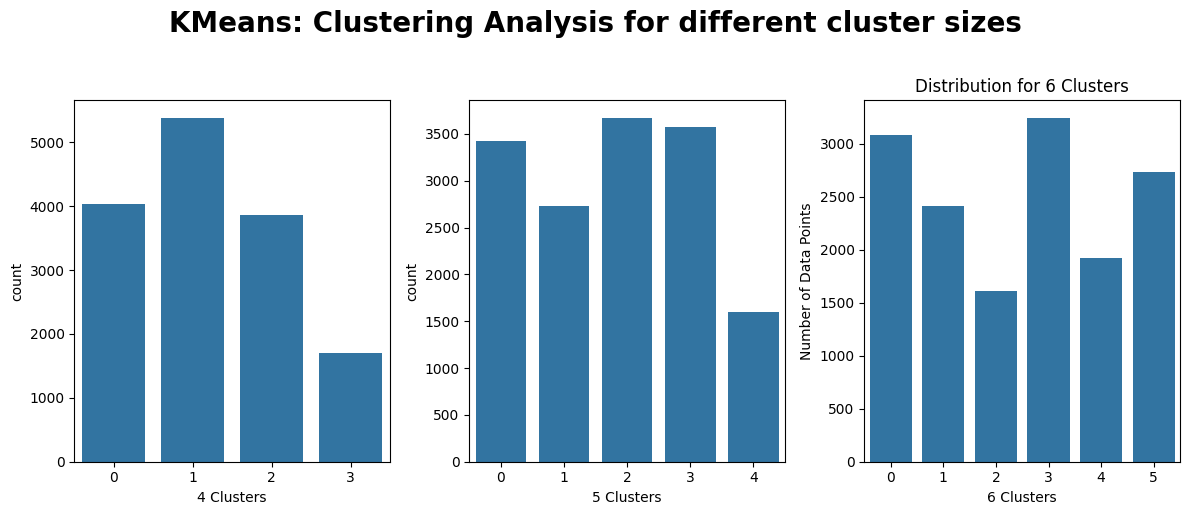

In [19]:
def DisplayCountPlotsForClusters(df_target, cluster_columns, plot_title):

    fig, axes = plt.subplots(1, len(cluster_columns), figsize=(12, 5))
    axes = axes.flatten()

    for i, col in enumerate(cluster_columns):

        sns.countplot(x=f'{col} Clusters', data=df_target, ax=axes[i])

        axes[2].set_xlabel(f'{col} Clusters')
        axes[2].set_ylabel('Number of Data Points')
        axes[2].set_title(f'Distribution for {col} Clusters')

    plt.suptitle(f'{plot_title}: Clustering Analysis for different cluster sizes', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout()
    plt.show()
    print()
    print()

features = ['satisfaction_level', 'last_evaluation']
clusterSizeColumns = [4, 5, 6]
df_kMeansClustering = df_employeeTurnOverScaled.copy(deep=True)

for k in [4, 5, 6]:
    model = KMeans(n_clusters=k, n_init=10, init='k-means++', random_state=315)
    df_kMeansClustering[f'{k} Clusters'] = model.fit_predict(
                                                                                df_kMeansClustering[features]
                                                                            )

DisplayCountPlotsForClusters(df_kMeansClustering, clusterSizeColumns, 'KMeans')


##### **Dimensionality Reduction Results for 4, 5 and 6 Clusters** #####
Since we've already reduced the dataset's features manually down to 3 features, </br>
there is no need for any addional dimensionality reduction.

##### **Plot KMeans Clustering for 4, 5 and 6 Nodes** #####

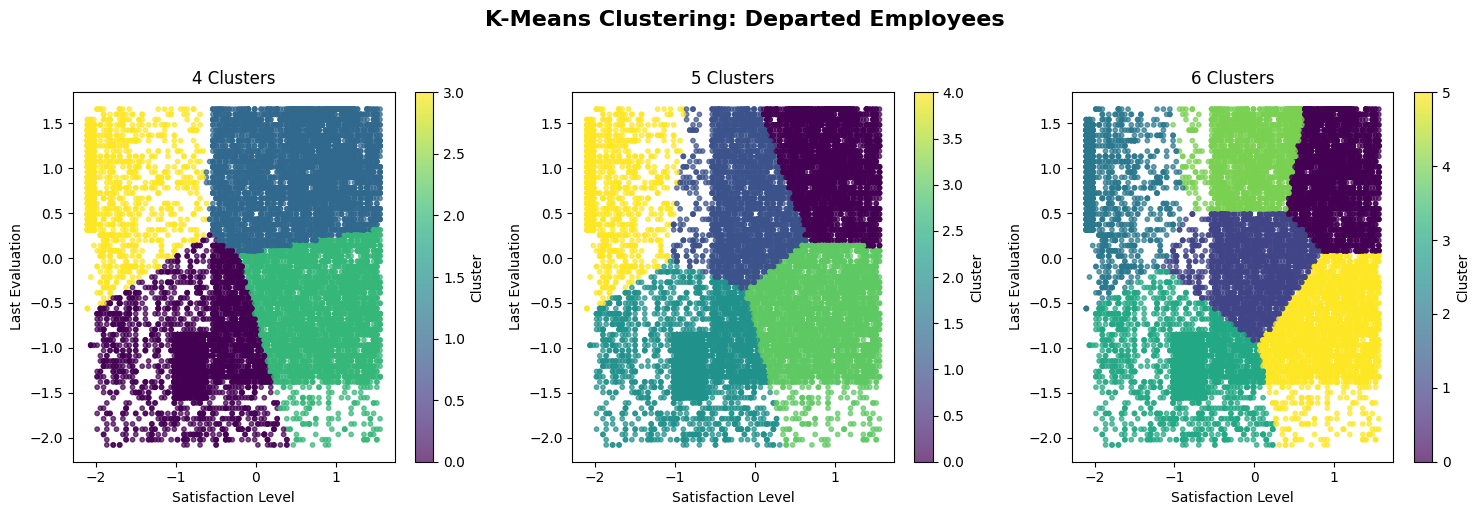

In [20]:
def DisplayScatterPlotsForClusters(df_target, cluster_columns, plot_title):

    fig, axes = plt.subplots(1, len(cluster_columns), figsize=(15, 5))

    for i, col in enumerate(cluster_columns):
        scatter = axes[i].scatter(
            df_target['satisfaction_level'], 
            df_target['last_evaluation'], 
            c=df_target[f'{col} Clusters'], 
            cmap='viridis', 
            s=10,
            alpha=0.7
        )
        axes[i].set_xlabel('Satisfaction Level')
        axes[i].set_ylabel('Last Evaluation')
        axes[i].set_title(f'{col} Clusters')
        plt.colorbar(scatter, ax=axes[i], label='Cluster')

    plt.suptitle(f'{plot_title} Clustering: Departed Employees', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

clusterColumns = ['4 Clusters', '5 Clusters', '6 Clusters']
DisplayScatterPlotsForClusters(df_kMeansClustering, clusterSizeColumns, 'K-Means')

#### **K-Means Clustering Plot Analysis** ####
##### **Optimal Number of Clusters** #####
The Elbow and Silhouette methods indicated that the optimal number of clusters for KMeans Clustering is 6.</br>
It seems like that number is a little high and the results maybe diluted and difficult to interpret.</br>
So, I decided to process and plot a range of cluster numbers; (4, 5, 6)</br>
Upon examination of the actual Scatter Plots, it appears that 4 Clusters gives the cleanest results.</br>
It offers the clearest delineation amongst the cluster groups with clear boundaries.</br>
There appear to be few, if any random points outside of the cluster regions </br>
The boundaries between the clusters became much more nebulous as the number of clusters increased.</br>
It's much easier to make business decisions and plans when the results of analysis are more clearly defined.</br>
</br>


#### **For Completeness, Plot results for Hierarchical and DBScan Clustering** ####
##### **Hierarchical Clustering** #####
Elbow method Optimal Clusters: 5</br>
Silhouette Scores Optimal Clusters: 2</br>
Plot 2, 3, 4, 5 Clusters (out of curiosity) </br>

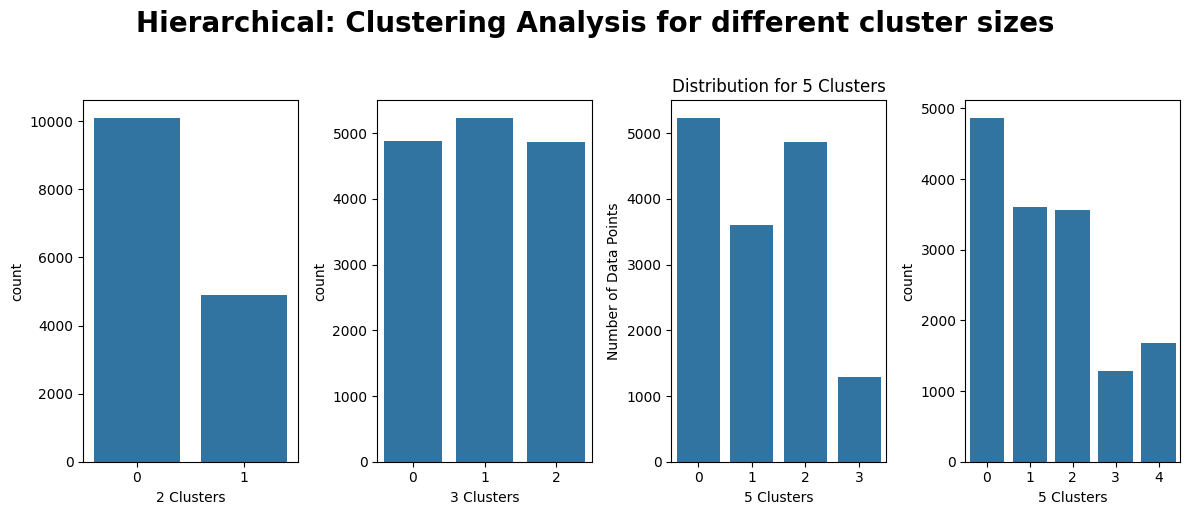

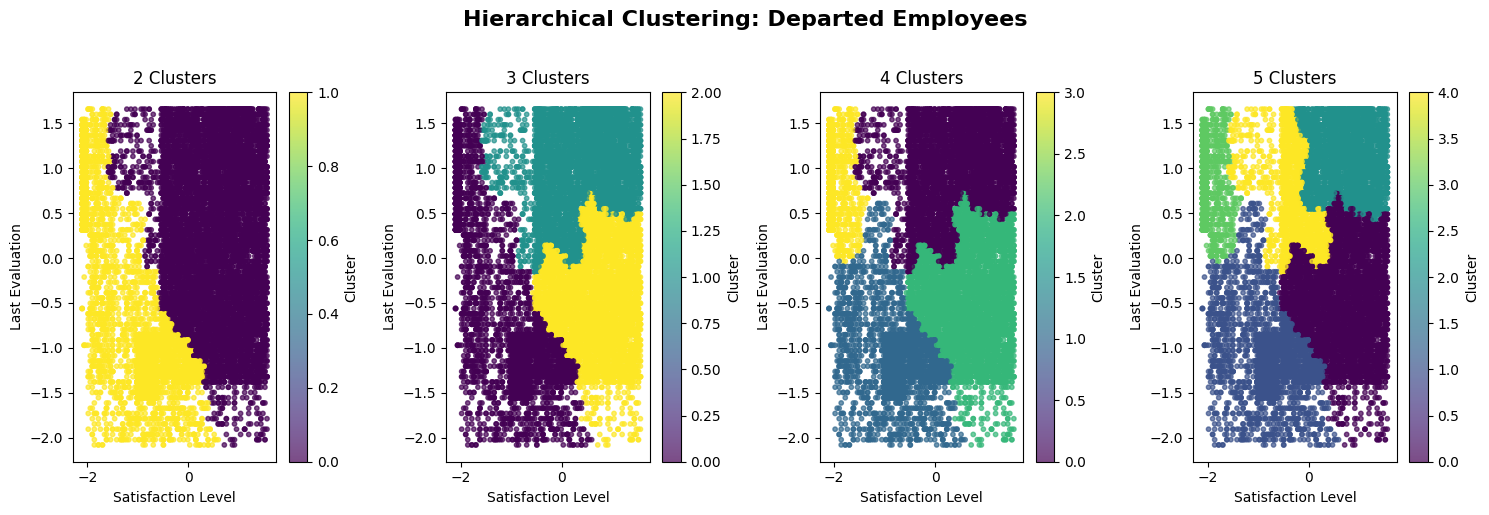

In [21]:
df_hierarchical = df_employeeTurnOverScaled.copy(deep=True)
clusterSizeColumns = [2, 3, 4, 5]

for k in clusterSizeColumns:
    model = AgglomerativeClustering(n_clusters=k)
    df_hierarchical[f'{k} Clusters'] = model.fit_predict(df_hierarchical[features])

DisplayCountPlotsForClusters(df_hierarchical, clusterSizeColumns, 'Hierarchical')
print()
DisplayScatterPlotsForClusters(df_hierarchical, clusterSizeColumns, 'Hierarchical')

#### **Hierarchical Clustering Plot Analysis** ####
##### **Optimal Number of Clusters** #####
Elbow and silhouette scores produced a significant spread in the optimum custer number</br>
Given that fact, it was worthwhile to examine clustering results for the entire range 2-5.</br>
Using 2 nodes produced too simple of a result. Looking at the plots for 4 and 5 clusters,</br>
the boundaries between the cluster groups become more convoluted.</br>
The optimal number that produces the clearest boundaries diversified results is 3 clusters.</br>
</br>


##### **DBScan Clustering** #####
Elbow method Optimal Clusters: 5</br>
Silhouette Scores Optimal Clusters: 2</br>
Plot 2, 3, 4 Clusters (out of curiosity) </br>


2 Clusters (eps=0.5): actual clusters=1, noise=0
3 Clusters (eps=0.109): actual clusters=9, noise=9
4 Clusters (eps=0.12): actual clusters=4, noise=5


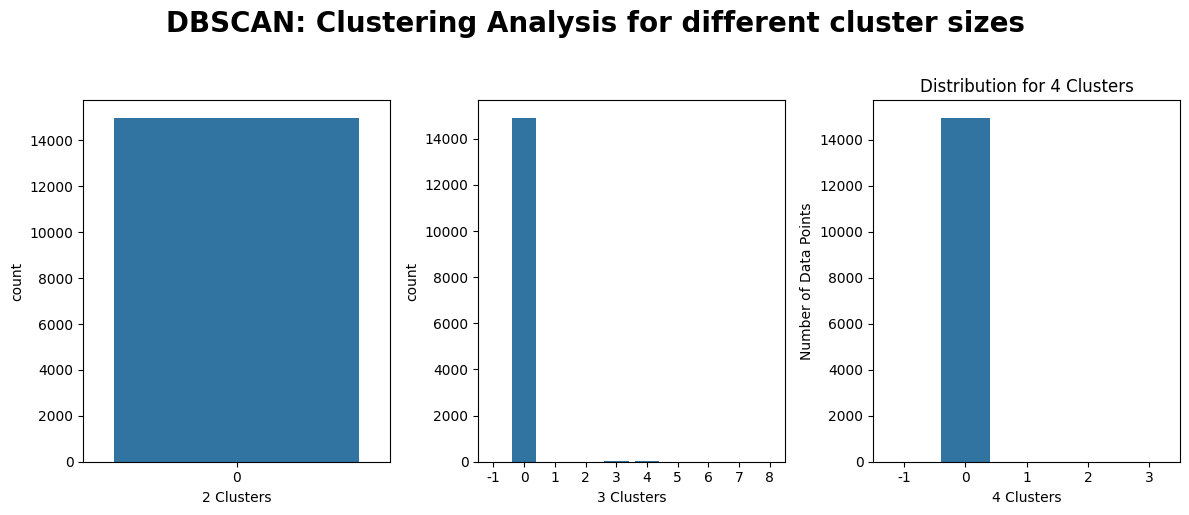

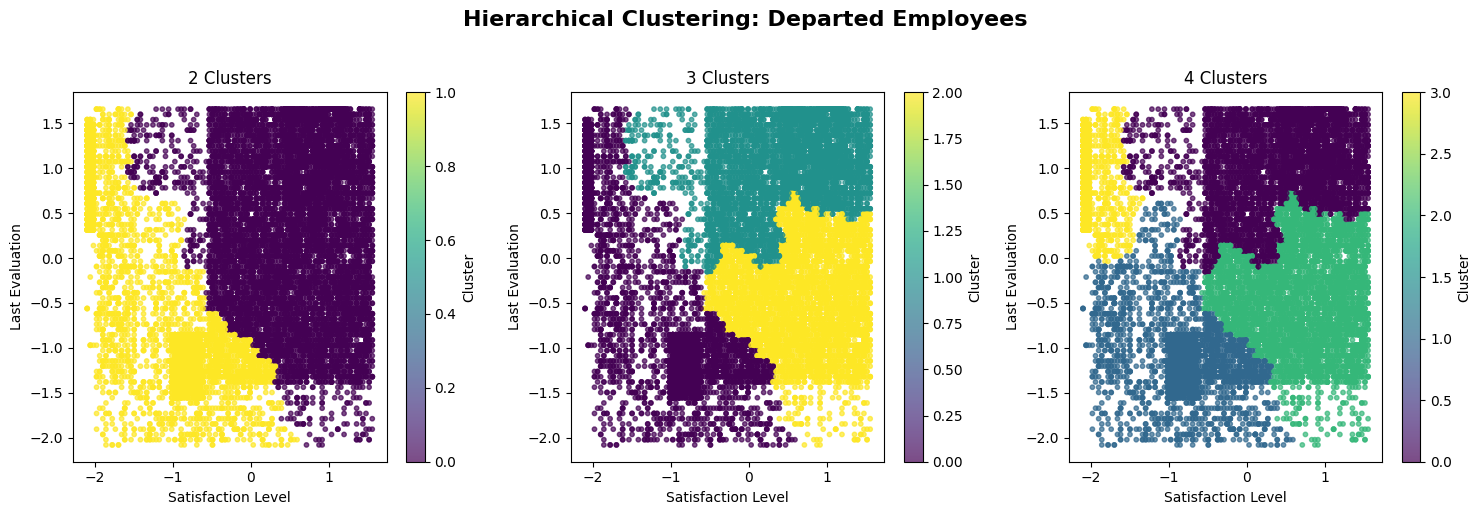

In [22]:
df_DBScan = df_employeeTurnOverScaled.copy(deep=True)
features = ['satisfaction_level', 'last_evaluation']
clusterSizeColumns = [2, 3, 4]

# Smaller eps values to get more clusters
eps_values = {
    '2 Clusters': 0.5,   
    '3 Clusters': 0.109,   
    '4 Clusters': 0.12,  
}

# Test to find actual cluster counts first
for label, eps in eps_values.items():
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(df_DBScan[features])
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = (labels == -1).sum()
    print(f"{label} (eps={eps}): actual clusters={n_clusters}, noise={noise_count}")

# Adjust eps values based on output above, then add to dataframe
for label, eps in eps_values.items():
    model = DBSCAN(eps=eps, min_samples=5)
    df_DBScan[label] = model.fit_predict(df_DBScan[features])

DisplayCountPlotsForClusters(df_DBScan, clusterSizeColumns, 'DBSCAN')
print()
DisplayScatterPlotsForClusters(df_hierarchical, clusterSizeColumns, 'Hierarchical')

##### **DBScan Clustering Analysis** #####
**After several attempts** attempting to optimize the eps to produce the desired number of clusters,</br>
I was ultimately unable to figure it out. This is clearly displayed in the distribution plots.</br>
Give this, it's difficult to arrive at any useful conclusiosn with any degree of confidence.</br>
The code remains in place to be revisited at a later date.

## <u>**4. Handling Class Imbalances**</u> ##
##### **Convert categorical features to numeric using get_dummies()** #####

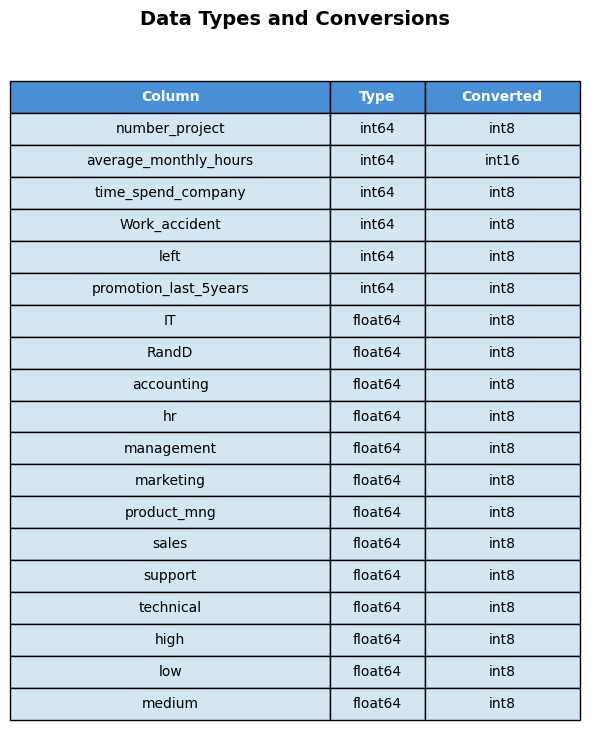

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,IT,RandD,accounting,hr,management,marketing,product_mng,sales,support,technical,high,low,medium
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,160,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,143,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
14997,0.11,0.96,6,280,4,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0


In [23]:
# Restore dataframe to state before one-hot-encoding
#
# # In a real world, I should have used either the get_dummies() or one_hot_encoding() technique 
# earlier in Data Wrangling.
# Since it is a requirement for the assignment to use get_dummies(), I will do that here.
# To do so I'm going to restore the dataframe, apply get_dummies() and do data conversion again here
df_employeeTurnOver = df_employeeTurnOverSaved.copy(deep=True)

departments = df_employeeTurnOver['department'].str.get_dummies()
df_employeeTurnOver = pd.concat([df_employeeTurnOver, df_employeeTurnOver['department'].str.get_dummies()], axis=1)
df_employeeTurnOver.drop('department', axis=1, inplace=True)

salaryLevels = df_employeeTurnOver['salary'].str.get_dummies()
df_employeeTurnOver = pd.concat([df_employeeTurnOver, df_employeeTurnOver['salary'].str.get_dummies()], axis=1)
df_employeeTurnOver.drop('salary', axis=1, inplace=True)

# Update types dataframe to remove hardwired prefixes
df_types['Column'] = df_types['Column'].str.replace('department_', '').str.replace('salary_', '')
DisplayTable(df_types, table_title='Data Types and Conversions', max_cell_length=60)

# Examine dataframe changes
PerformDataConversion(df_employeeTurnOver, remove_class_prefix=True)

#PrintDataFrameStatistics(df_employeeTurnOver, display_table=True)




#### **Use SMOTE Technique to Handle Class Imbalances** ####
SMOTE - Synthetic Minority Over-sampling Technique

##### **Plot 'left' Feature Column Distribution** #####

##### Test/Train Split and Scale the dataset #####

In [24]:
# # Separate features and target variable
X = df_employeeTurnOver.drop('left', axis=1)
y = df_employeeTurnOver['left']

# Test/Train Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Standardize the feature variables
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

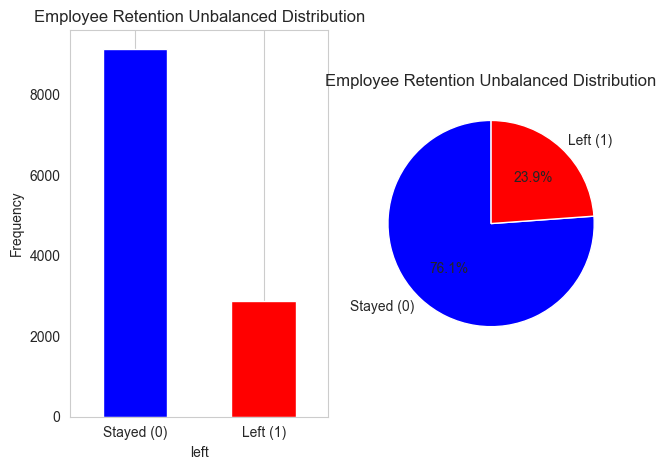


Scatter Plot Unbalanced Data




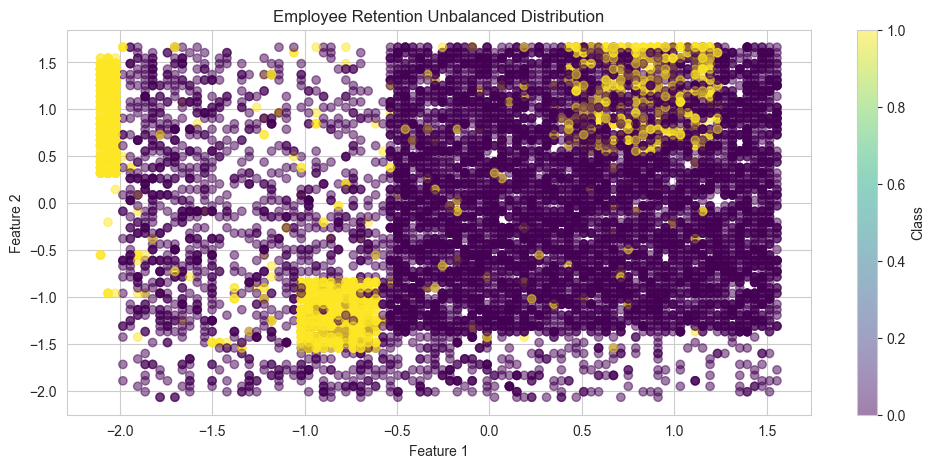

In [47]:

def DisplayDataFeatureBalancePlots(x_data, y_data, plot_title=None):

    if plot_title is None:
        title='Class Distributions'
    else:
        title = plot_title

    leftCounts = y_data.value_counts().sort_index()

    plt.subplot(1, 2, 1)
    leftCounts.plot(kind='bar', color=['blue', 'red'])
    plt.title(title)
    plt.xlabel('left')
    plt.ylabel('Frequency')
    plt.xticks(ticks=[0, 1], labels=['Stayed (0)', 'Left (1)'], rotation=0)
    plt.grid(axis='y')

    # Plot the distribution of the 'Class' column as a pie chart
    plt.subplot(1, 2, 2)
    leftCounts.plot(kind='pie', labels=['Stayed (0)', 'Left (1)'], colors=['blue', 'red'], autopct='%1.1f%%', startangle=90)
    plt.title(title)
    plt.ylabel('')

    # Show the plots
    plt.tight_layout()
    plt.show()
    print()

    print("Scatter Plot Unbalanced Data")
    # Scatter plot for the imbalanced data
    plt.figure(figsize=(12, 5))
    plt.scatter(x_data[:, 0], x_data[:, 1], c=y_data, alpha=0.5, cmap='viridis', marker='o')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar(label='Class')
    print()
    print()

DisplayDataFeatureBalancePlots(x_data=X_train_sc, 
                               y_data=y_train, 
                               plot_title='Employee Retention Unbalanced Distribution')


##### **Plot 'left' Feature Column Distribution Analysis** #####
Roughly 76% of the employees stayed, while 24% left.</br>
This leads to significant imbalance weighted towards employees staying. </br>
There is much higher number of purple points (employees who stayed) visible </br>
in the above scatter plot of the unbalanced distribution.</br>
This could affect overall model performance. The was to remedy this is </br>
to boost the minority class through **SMOTE** technique.

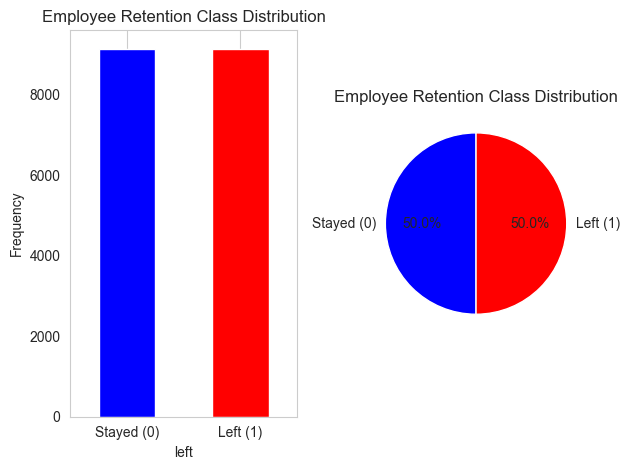


Scatter Plot Unbalanced Data




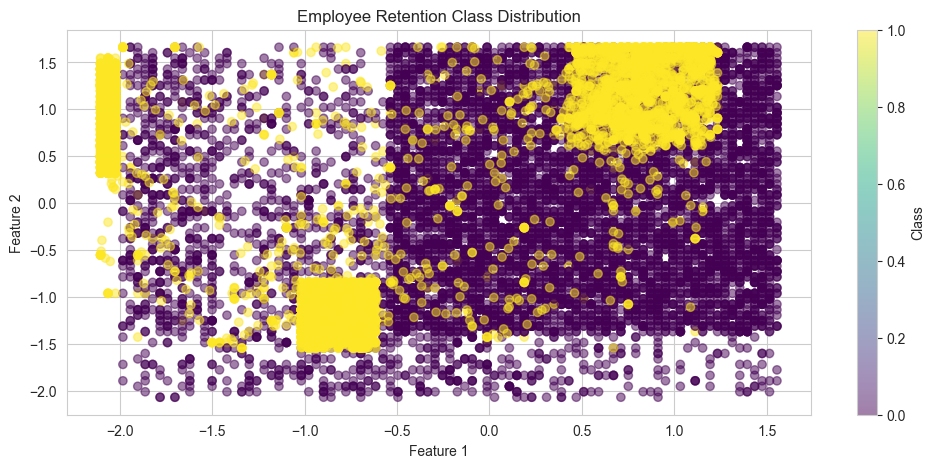

In [48]:
#
# SMOTE Directly from 20.3 Classification Part 3
# 

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)


# Plot the results
DisplayDataFeatureBalancePlots(x_data=X_train_smote, 
                               y_data=y_train_smote, 
                               plot_title='Employee Retention Class Distribution')


##### **Results of SMOTE Balancing of 'left' feature column** #####
Based on the above plots, we can see the employee retention feature (left) is much more balanced (50/50)

## <u>**5. Model Training and Cross-Validation**</u> ##
##### **Classification Models Utility Functions** #####


In [ ]:
#
# LogisticRegression
# 
def RunLogisticRegression(df_target=None, target_label=None, plot_title=None, 
                          apply_scaling=False, apply_pca=False,
                          X_train=None, X_test=None, y_train=None, y_test=None,
                          feature_names=None):
    
    # Use the provided pre-split (SMOTE) data
    if X_train is not None and X_test is not None and y_train is not None and y_test is not None:

        X = None 
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]
    else:
        # Perform Test/Train Split here
        X = df_target.drop(target_label, axis=1)
        y = df_target[target_label]
        feature_names = X.columns
        
        # Split Data into Training/Test => 80/20
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

        if apply_scaling == True:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        if apply_pca:
            pca = PCA(n_components=0.95)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            print(f'PCA Components: {pca.n_components_}')
            print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
            print()

    # Balanced Class Weight 
    model = LogisticRegression(random_state=315, max_iter=1000, class_weight='balanced')
    model.fit(X_train, y_train)

    # Predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print(f'{plot_title} LOGISTIC REGRESSION RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    # Classification Report (includes precision, recall, F1)
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    report = classification_report(y_test, test_predictions, output_dict=True)
    print(report)
    print()

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Logistic Regression - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    # Feature Importance
    print('-' * 60)
    print(f'{plot_title} FEATURE IMPORTANCE')
    print('-' * 60)
    
    avg_importance = pd.Series(
        np.abs(model.coef_).mean(axis=0),
        index=feature_names
    ).sort_values(ascending=False)
    
    print(avg_importance)
    print()

    plt.figure(figsize=(10, 6))
    avg_importance.sort_values().plot(kind='barh')
    plt.xlabel('Average Absolute Coefficient')
    plt.title(f'{plot_title} Feature Importance - Logistic Regression', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
            'model': model,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'f1_score': test_f1,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test, 
            'test_predictions': test_predictions,
            'report': report
        }


#
# RandomForestClassifier
# 
def RunRandomForestClassifier(df_target=None, target_label=None, plot_title=None, 
                              apply_scaling=False, apply_pca=False,
                              X_train=None, X_test=None, y_train=None, y_test=None,
                              feature_names=None):

    # Use the provided pre-split (SMOTE) data
    if X_train is not None and X_test is not None and y_train is not None and y_test is not None:
        X = None
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]
    else:
        # Perform Test/Train Split here
        X = df_target.drop(target_label, axis=1)
        y = df_target[target_label]
        feature_names = X.columns

        # Split Data into Training/Test => 80/20
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

        if apply_scaling == True:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # PCA - after scaling, before model
        if apply_pca:
            pca = PCA(n_components=0.95)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            print(f'PCA Components: {pca.n_components_}')
            print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
            print()             

    # Balanced Class Weight 
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=315,
        n_jobs=-1,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)

    # Predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print(f'{plot_title} RANDOM FOREST CLASSIFIER RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    # Classification Report
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    report = classification_report(y_test, test_predictions, output_dict=True)
    print(report)
    print()

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Random Forest - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    # Feature Importance
    print('-' * 60)
    print(f'{plot_title} FEATURE IMPORTANCE')
    print('-' * 60)
    
    # RandomForest uses feature_importances_ (not coef_)
    feature_importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)
    
    print(feature_importance)
    print()

    plt.figure(figsize=(10, 6))
    feature_importance.sort_values().plot(kind='barh')
    plt.xlabel('Feature Importance (Gini)')
    plt.title(f'{plot_title} Feature Importance - Random Forest', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
            'model': model,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'f1_score': test_f1,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test, 
            'test_predictions': test_predictions,
            'report': report
        }

#
# GradientBoostingClassifier
# 
def RunGradientBoostingClassifier(df_target=None, target_label=None, plot_title=None, 
                                  apply_scaling=False, apply_pca=False,
                                  X_train=None, X_test=None, y_train=None, y_test=None,
                                  feature_names=None):

    # Use the provided pre-split (SMOTE) data
    if X_train is not None and X_test is not None and y_train is not None and y_test is not None:
        X = None
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]
    else:
        # Perform Test/Train Split here
        X = df_target.drop(target_label, axis=1)
        y = df_target[target_label]
        feature_names = X.columns

        # Split Data into Training/Test => 80/20
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

        if apply_scaling == True:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # PCA - after scaling, before model
        if apply_pca:
            pca = PCA(n_components=0.95)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            print(f'PCA Components: {pca.n_components_}')
            print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
            print()

    # Gradient Boosting Classifier
    # Note: GradientBoostingClassifier does not support class_weight parameter
    # Using SMOTE data handles class imbalance instead
    model = GradientBoostingClassifier(
                                        n_estimators=100,
                                        learning_rate=0.1,
                                        max_depth=3,
                                        min_samples_split=2,
                                        min_samples_leaf=1,
                                        max_features='sqrt',
                                        random_state=315
                                    )
    model.fit(X_train, y_train)

    #
    # Predictions
    #
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    #
    # Metrics
    #
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print(f'{plot_title} GRADIENT BOOSTING CLASSIFIER RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    #
    # Classification Report (includes precision, recall, F1)
    #
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    report = classification_report(y_test, test_predictions, output_dict=True)
    print(report)
    print()

    #
    # Confusion Matrix
    #
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Gradient Boosting - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    #
    # Feature Importance
    #
    print('-' * 60)
    print(f'{plot_title} FEATURE IMPORTANCE')
    print('-' * 60)
    
    # GradientBoosting uses feature_importances_ (like RandomForest)
    feature_importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)
    
    print(feature_importance)
    print()

    plt.figure(figsize=(10, 6))
    feature_importance.sort_values().plot(kind='barh')
    plt.xlabel('Feature Importance')
    plt.title(f'{plot_title} Feature Importance - Gradient Boosting', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
            'model': model,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'f1_score': test_f1,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test, 
            'test_predictions': test_predictions,
            'report': report
        }



def CompareClassificationResults(results_dict, title='Classifier Comparison'):
    
    sns.set_style("whitegrid")
    
    #
    # 1. Calculate all metrics
    #
    metrics_data = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        report = results['report']
        
        metrics_data.append({
            'Model': name,
            'Train Accuracy': results['train_accuracy'],
            'Test Accuracy': results['test_accuracy'],
            'Balanced Accuracy': balanced_accuracy_score(y_test, test_predictions),
            'Precision': precision_score(y_test, test_predictions, average='weighted'),
            'Recall': recall_score(y_test, test_predictions, average='weighted'),
            'F1 Score': results['f1_score'],
            'Gap': results['train_accuracy'] - results['test_accuracy']
        })
    
    df_comparisons = pd.DataFrame(metrics_data).set_index('Model')
    
    #
    # 2. Print Metrics Table
    #
    print('=' * 70)
    print(title)
    print('=' * 70)
    print(df_comparisons.round(4))
    print()

    DisplayTable(df_comparisons, 'Classification Comparisons',show_index=True)
    
    #
    # 3. Accuracy Comparison (Train vs Test vs Balanced)
    #
    accuracy_metrics = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        
        accuracy_metrics.append({'Model': name, 'Metric': 'Train Accuracy', 'Score': results['train_accuracy']})
        accuracy_metrics.append({'Model': name, 'Metric': 'Test Accuracy', 'Score': results['test_accuracy']})
        accuracy_metrics.append({'Model': name, 'Metric': 'Balanced Accuracy', 'Score': balanced_accuracy_score(y_test, test_predictions)})
    
    acc_df = pd.DataFrame(accuracy_metrics)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=acc_df, x='Metric', y='Score', hue='Model', palette='deep')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    plt.title('Accuracy Metrics Comparison', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 4. Precision / Recall / F1 Comparison
    #
    prf_metrics = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        
        prf_metrics.append({'Model': name, 'Metric': 'Precision', 'Score': precision_score(y_test, test_predictions, average='weighted')})
        prf_metrics.append({'Model': name, 'Metric': 'Recall', 'Score': recall_score(y_test, test_predictions, average='weighted')})
        prf_metrics.append({'Model': name, 'Metric': 'F1 Score', 'Score': results['f1_score']})
    
    prf_df = pd.DataFrame(prf_metrics)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=prf_df, x='Metric', y='Score', hue='Model', palette='Set2')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    plt.title('Precision / Recall / F1 Comparison', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 5. Gap Comparison (Overfitting indicator)
    #
    gap_data = pd.DataFrame({
        'Model': list(results_dict.keys()),
        'Gap': [r['train_accuracy'] - r['test_accuracy'] for r in results_dict.values()]
    })
    
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=gap_data, x='Model', y='Gap', palette='deep')
    ax.bar_label(ax.containers[0], fmt='%.4f', fontsize=10)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.title('Overfitting Indicator (Lower is Better)', fontweight='bold')
    plt.ylabel('Train - Test Accuracy Gap')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 6. Confusion Matrices
    #
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    palettes = ['Blues', 'Greens', 'Oranges', 'Purples']
    
    for i, (name, results) in enumerate(results_dict.items()):
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        cm = confusion_matrix(y_test, test_predictions)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap=palettes[i % len(palettes)], 
                    ax=axes[i], cbar=True)
        axes[i].set_title(f'{name}', fontweight='bold')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    
    plt.suptitle('Confusion Matrix Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 7. Metrics Heatmap
    #
    plt.figure(figsize=(12, len(results_dict) * 0.8 + 2))
    heatmap_cols = ['Test Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 Score']
    sns.heatmap(df_comparisons[heatmap_cols], annot=True, fmt='.4f', cmap='YlGnBu', 
                vmin=0, vmax=1, linewidths=0.5)
    plt.title('Model Metrics Heatmap', fontweight='bold')
    plt.tight_layout()
    plt.show()

    #
    # 8. Plot Classification Report Results
    #
    for i, (name, results) in enumerate(results_dict.items()):

        report = results['report']
        df_result = pd.DataFrame(report)
        DisplayTable(df_result, 
                     f'{name} Classification Report',
                     show_index=True)
    
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4))

    if n_models == 1:
        axes = [axes]

    for i, (name, results) in enumerate(results_dict.items()):
        report = results['report']
        df_report = pd.DataFrame(report).T
        
        # Keep only class rows and main metrics
        df_report = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
        df_report = df_report.drop(columns=['support'], errors='ignore')
        
        sns.heatmap(df_report, annot=True, fmt='.2f', cmap='RdYlGn',
                    vmin=0, vmax=1, ax=axes[i], linewidths=0.5)
        axes[i].set_title(f'{name}', fontweight='bold')
        axes[i].set_ylabel('Class')
        axes[i].set_xlabel('Metric')

    plt.suptitle('Classification Reports Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return df_comparisons

def CheckClusterDistributions(df_target, feature_name, title):
    print(f'{title} Cluster Distribution Comparisons')
    valueCounts = df_target[feature_name].value_counts()
    print(f'ValueCounts: {valueCounts}')
    normalizedValueCounts = df_target[feature_name].value_counts(normalize=True) * 100
    print(f'NormalizedValueCounts: {normalizedValueCounts}')
    print()

##### **Cross Validation Utility Functions** #####

In [50]:
def ApplyCrossValidationClassification(model, X, y, plot_label):

    # Split for train/test calculation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

    # Fit model and calculate train/test metrics
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    test_f1 = f1_score(y_test, model.predict(X_test), average='weighted')

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Cross-validation for Accuracy
    cv_accuracy = cross_val_score(model, X, y, scoring='accuracy', n_jobs=-1, cv=kf)

    # Cross-validation for F1 Score
    cv_f1 = cross_val_score(model, X, y, scoring='f1_weighted', n_jobs=-1, cv=kf)

    # Accuracy stats
    acc_mean = np.mean(cv_accuracy)
    acc_std = np.std(cv_accuracy)
    acc_moe = 1.96 * acc_std / np.sqrt(len(cv_accuracy))

    # F1 stats
    f1_mean = np.mean(cv_f1)
    f1_std = np.std(cv_f1)
    f1_moe = 1.96 * f1_std / np.sqrt(len(cv_f1))

    print(plot_label)
    print(f'Mean CV Accuracy: {acc_mean:.4f} ± {acc_moe:.4f}')
    print(f'95% CI Accuracy: {acc_mean - acc_moe:.4f} to {acc_mean + acc_moe:.4f}')
    print(f'Mean CV F1 Score: {f1_mean:.4f} ± {f1_moe:.4f}')
    print(f'95% CI F1: {f1_mean - f1_moe:.4f} to {f1_mean + f1_moe:.4f}')
    print(f'Train Accuracy: {train_accuracy:.4f}')
    print(f'Test Accuracy: {test_accuracy:.4f}')
    print(f'Test F1 Score: {test_f1:.4f}')

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy boxplot
    axes[0].boxplot(cv_accuracy)
    axes[0].axhline(acc_mean - acc_moe, linestyle='--', color='teal', label='95% CI')
    axes[0].axhline(acc_mean + acc_moe, linestyle='--', color='teal')
    axes[0].axhline(test_accuracy, color='purple', label='Test Accuracy')
    axes[0].axhline(train_accuracy, color='red', label='Train Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'CV Accuracy - {plot_label}')
    axes[0].legend(loc='best')

    # F1 boxplot
    axes[1].boxplot(cv_f1)
    axes[1].axhline(f1_mean - f1_moe, linestyle='--', color='teal', label='95% CI')
    axes[1].axhline(f1_mean + f1_moe, linestyle='--', color='teal')
    axes[1].axhline(test_f1, color='purple', label='Test F1')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title(f'CV F1 Score - {plot_label}')
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

    print()
    print()

    return {'cv_accuracy': cv_accuracy, 'cv_f1': cv_f1}

##### **Logistic Regression** #####

Logistic Regression
Employee Retention (SMOTE) LOGISTIC REGRESSION RESULTS
Training Accuracy: 0.7755
Testing Accuracy:  0.7580
Testing F1 Score:  0.7738
Gap:               0.0175

------------------------------------------------------------
Employee Retention (SMOTE) TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.9232017306652245, 'recall': 0.7450894805761676, 'f1-score': 0.8246376811594203, 'support': 2291.0}, '1': {'precision': 0.4926151172893136, 'recall': 0.7997179125528914, 'f1-score': 0.6096774193548387, 'support': 709.0}, 'accuracy': 0.758, 'macro avg': {'precision': 0.707908423977269, 'recall': 0.7724036965645296, 'f1-score': 0.7171575502571295, 'support': 3000.0}, 'weighted avg': {'precision': 0.8214397610373843, 'recall': 0.758, 'f1-score': 0.7738354059529374, 'support': 3000.0}}



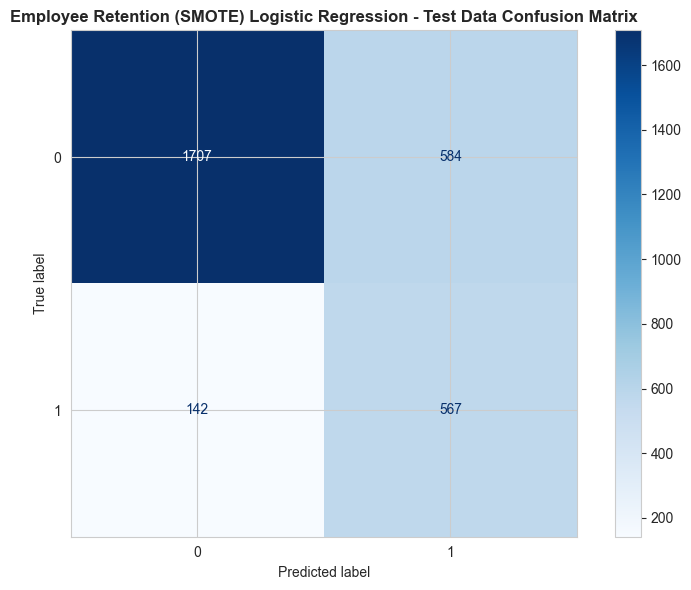


------------------------------------------------------------
Employee Retention (SMOTE) FEATURE IMPORTANCE
------------------------------------------------------------
satisfaction_level       1.112937
time_spend_company       0.695789
Work_accident            0.627431
number_project           0.518963
high                     0.398473
average_monthly_hours    0.245704
last_evaluation          0.237727
low                      0.235755
promotion_last_5years    0.219844
management               0.110611
RandD                    0.104542
technical                0.080212
hr                       0.064568
product_mng              0.044689
sales                    0.032910
IT                       0.032278
marketing                0.028219
accounting               0.025801
support                  0.019042
medium                   0.018004
dtype: float64



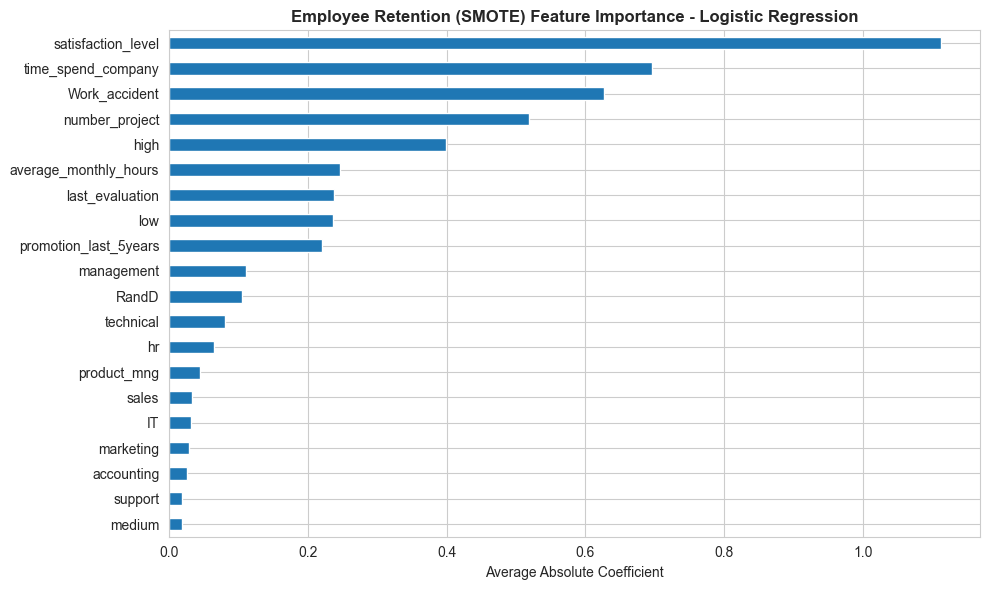

Logistic Regression 5-Fold CV
Mean CV Accuracy: 0.7752 ± 0.0045
95% CI Accuracy: 0.7707 to 0.7797
Mean CV F1 Score: 0.7750 ± 0.0046
95% CI F1: 0.7705 to 0.7796
Train Accuracy: 0.7758
Test Accuracy: 0.7729
Test F1 Score: 0.7729


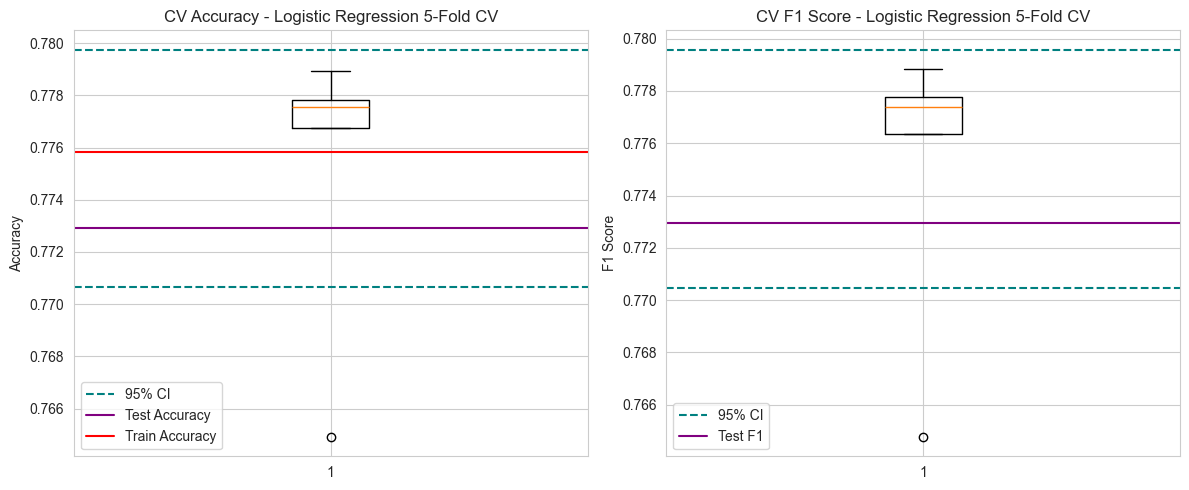

{'cv_accuracy': array([0.77783858, 0.77893297, 0.77674419, 0.77756498, 0.76491516]),
 'cv_f1': array([0.77777637, 0.77884772, 0.7763686 , 0.77737223, 0.76476324])}

In [51]:
# Get feature names before scaling (from original X)
feature_names = X.columns  

# Call with SMOTE data
print('Logistic Regression')
logisticRegressionResults = RunLogisticRegression(
                                                    plot_title='Employee Retention (SMOTE)',
                                                    X_train=X_train_smote,     
                                                    X_test=X_test_sc,          
                                                    y_train=y_train_smote,     
                                                    y_test=y_test,             
                                                    feature_names=feature_names
                                                )

ApplyCrossValidationClassification(
                                    logisticRegressionResults['model'], 
                                    X_train_smote,     
                                    y_train_smote,      
                                    'Logistic Regression 5-Fold CV'
                                )

##### **Logistic Regression Classification Results Analysis** #####


##### **Random Forest Classification** #####

Random Forest Classifier
Employee Retention (SMOTE) RANDOM FOREST CLASSIFIER RESULTS
Training Accuracy: 1.0000
Testing Accuracy:  0.9900
Testing F1 Score:  0.9900
Gap:               0.0100

------------------------------------------------------------
Employee Retention (SMOTE) TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.9925925925925926, 'recall': 0.994325621999127, 'f1-score': 0.9934583515045792, 'support': 2291.0}, '1': {'precision': 0.9815602836879432, 'recall': 0.9760225669957687, 'f1-score': 0.9787835926449788, 'support': 709.0}, 'accuracy': 0.99, 'macro avg': {'precision': 0.9870764381402679, 'recall': 0.9851740944974479, 'f1-score': 0.986120972074779, 'support': 3000.0}, 'weighted avg': {'precision': 0.9899852902547938, 'recall': 0.99, 'f1-score': 0.9899902168274269, 'support': 3000.0}}



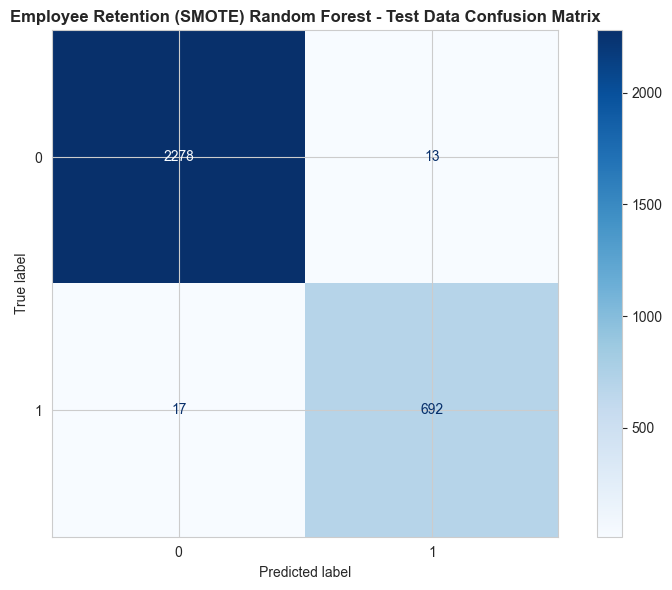


------------------------------------------------------------
Employee Retention (SMOTE) FEATURE IMPORTANCE
------------------------------------------------------------
satisfaction_level       0.266043
time_spend_company       0.228539
number_project           0.177834
average_monthly_hours    0.145184
last_evaluation          0.121997
Work_accident            0.018046
low                      0.006927
high                     0.006904
technical                0.004637
medium                   0.004077
sales                    0.003788
support                  0.003093
promotion_last_5years    0.002136
accounting               0.002096
IT                       0.001823
management               0.001807
hr                       0.001708
RandD                    0.001320
marketing                0.001046
product_mng              0.000994
dtype: float64



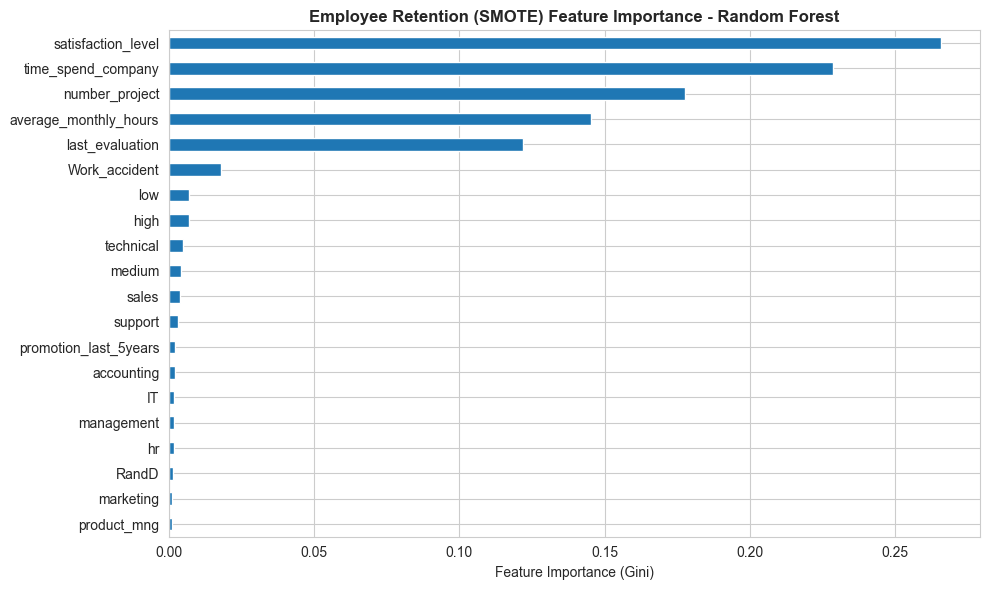

Random Forest 5-Fold CV
Mean CV Accuracy: 0.9887 ± 0.0017
95% CI Accuracy: 0.9870 to 0.9905
Mean CV F1 Score: 0.9887 ± 0.0017
95% CI F1: 0.9870 to 0.9905
Train Accuracy: 1.0000
Test Accuracy: 0.9844
Test F1 Score: 0.9844


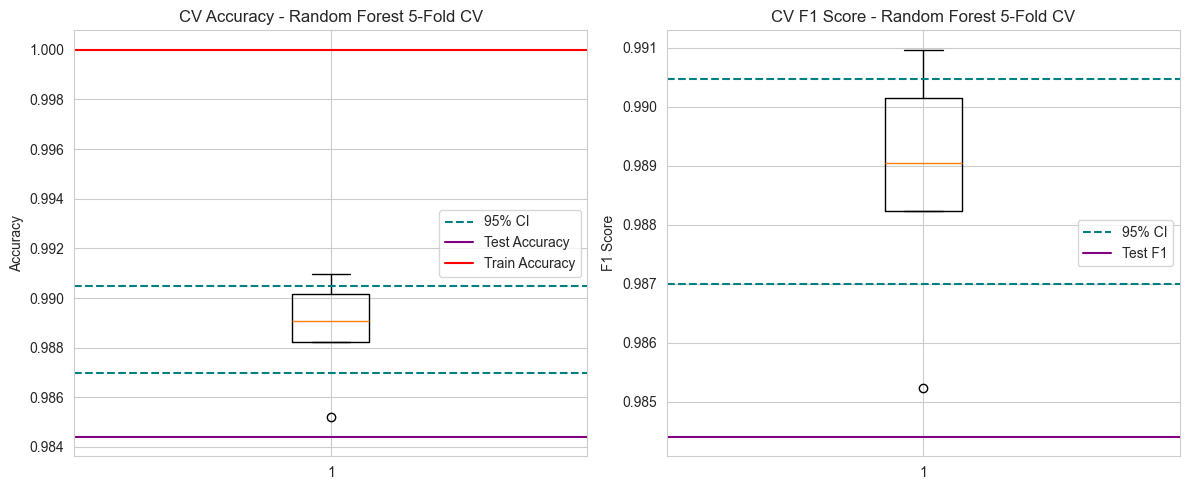

In [52]:
print('Random Forest Classifier')
randomForestResults = RunRandomForestClassifier(
                                                plot_title='Employee Retention (SMOTE)',
                                                X_train=X_train_smote,     
                                                X_test=X_test_sc,          
                                                y_train=y_train_smote,     
                                                y_test=y_test,             
                                                feature_names=feature_names
                                            )

# Cross-validation
ApplyCrossValidationClassification(
                                    randomForestResults['model'], 
                                    X_train_smote,      
                                    y_train_smote,      
                                    'Random Forest 5-Fold CV'
                                )

print()

##### **Random Forest Classiification Results Analysis** #####

##### **Gradient Boosting Classifier** #####

Gradient Boosting Classifier
Employee Retention (SMOTE) GRADIENT BOOSTING CLASSIFIER RESULTS
Training Accuracy: 0.9610
Testing Accuracy:  0.9603
Testing F1 Score:  0.9605
Gap:               0.0007

------------------------------------------------------------
Employee Retention (SMOTE) TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.9784140969162995, 'recall': 0.9694456569183763, 'f1-score': 0.9739092304319228, 'support': 2291.0}, '1': {'precision': 0.9041095890410958, 'recall': 0.9308885754583921, 'f1-score': 0.9173036831132731, 'support': 709.0}, 'accuracy': 0.9603333333333334, 'macro avg': {'precision': 0.9412618429786976, 'recall': 0.9501671161883842, 'f1-score': 0.9456064567725979, 'support': 3000.0}, 'weighted avg': {'precision': 0.9608534648884597, 'recall': 0.9603333333333334, 'f1-score': 0.9605314527489486, 'support': 3000.0}}



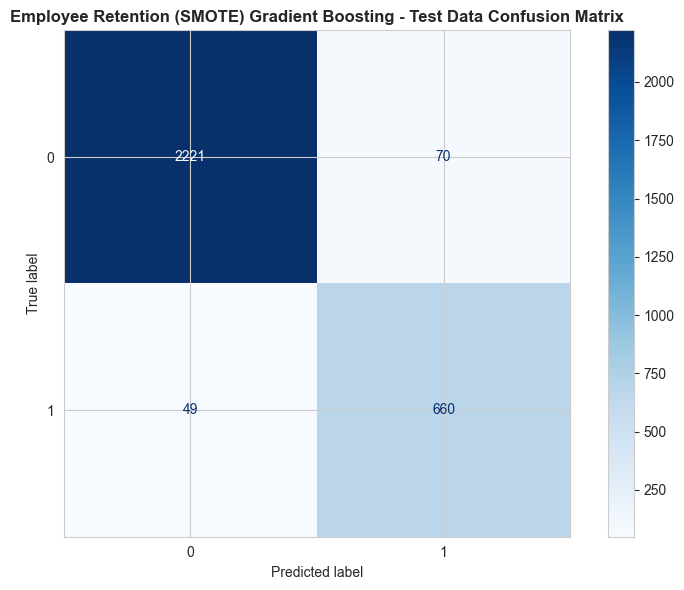


------------------------------------------------------------
Employee Retention (SMOTE) FEATURE IMPORTANCE
------------------------------------------------------------
satisfaction_level       0.272939
time_spend_company       0.252405
number_project           0.224445
last_evaluation          0.104779
average_monthly_hours    0.089978
Work_accident            0.027969
high                     0.009431
low                      0.008577
medium                   0.002993
promotion_last_5years    0.002060
technical                0.001235
RandD                    0.000899
management               0.000626
sales                    0.000423
product_mng              0.000381
support                  0.000372
accounting               0.000196
marketing                0.000101
IT                       0.000099
hr                       0.000092
dtype: float64



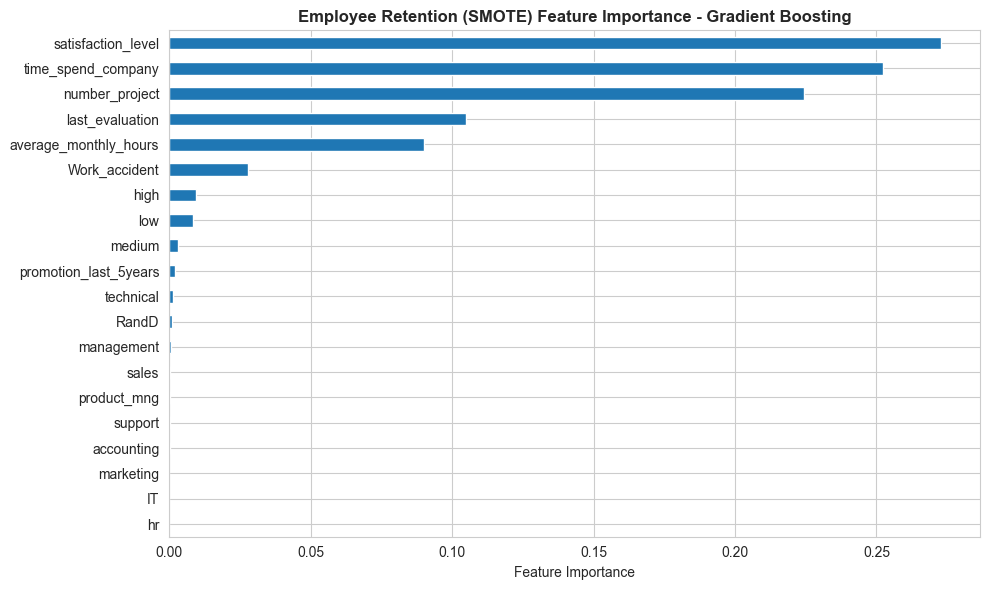

Gradient Boosting 5-Fold CV
Mean CV Accuracy: 0.9596 ± 0.0028
95% CI Accuracy: 0.9568 to 0.9624
Mean CV F1 Score: 0.9596 ± 0.0028
95% CI F1: 0.9568 to 0.9624
Train Accuracy: 0.9622
Test Accuracy: 0.9590
Test F1 Score: 0.9590


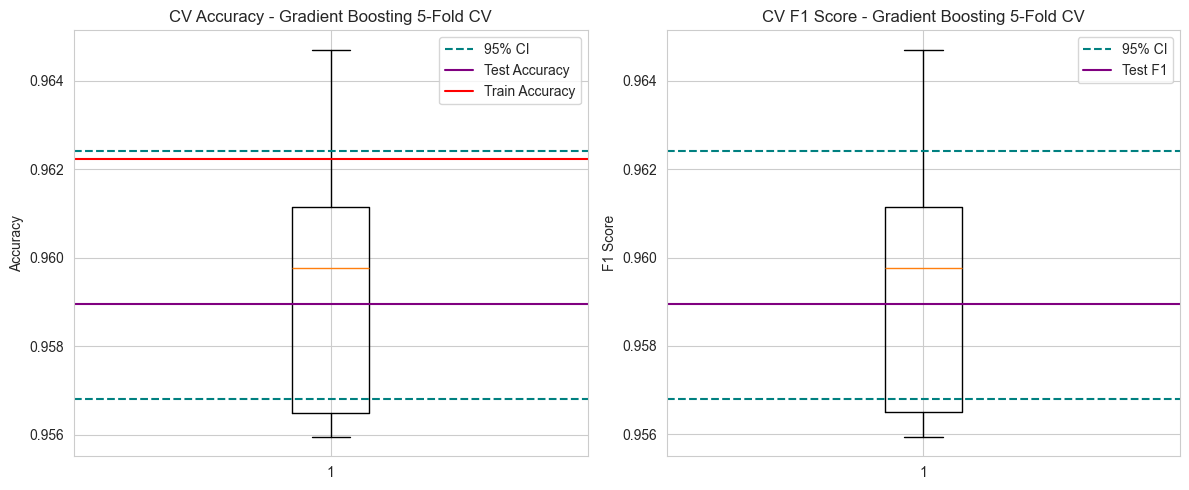

{'cv_accuracy': array([0.95595075, 0.95649795, 0.96114911, 0.96470588, 0.95977011]),
 'cv_f1': array([0.95593586, 0.95649875, 0.96114256, 0.96470712, 0.95975936])}

In [53]:
# Call with SMOTE data
print('Gradient Boosting Classifier')
gradientBoostingResults = RunGradientBoostingClassifier(
                                                        plot_title='Employee Retention (SMOTE)',
                                                        X_train=X_train_smote,     
                                                        X_test=X_test_sc,          
                                                        y_train=y_train_smote,     
                                                        y_test=y_test,             
                                                        feature_names=feature_names
                                                    )

# Cross-validation
ApplyCrossValidationClassification(
                                    gradientBoostingResults['model'], 
                                    X_train_smote,      
                                    y_train_smote,      
                                    'Gradient Boosting 5-Fold CV'
                                )

##### **Gradient Boosting Classifier Analysis** #####

##### **Compare Results of LogisticRegression, RandomForestClassifier, GradientBoostingClassifier** #####

Double check the Classification Results


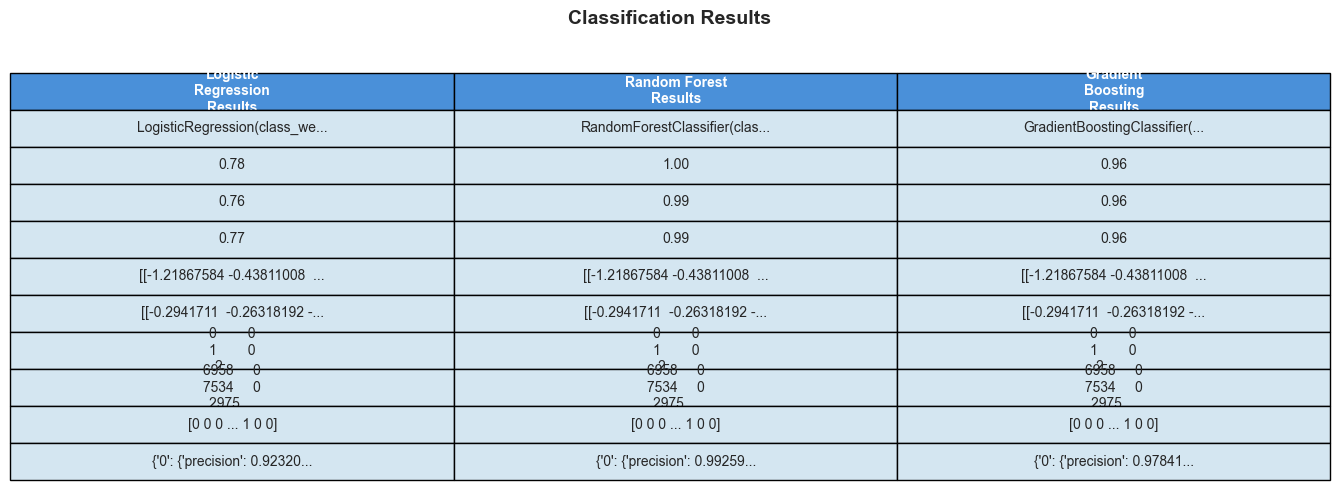



Classification Model Results
                             Train Accuracy  Test Accuracy  Balanced Accuracy  \
Model                                                                           
Logistic Regression Results          0.7755         0.7580             0.7722   
Random Forest Results                1.0000         0.9900             0.9829   
Gradient Boosting Results            0.9610         0.9603             0.9508   

                             Precision  Recall  F1 Score     Gap  
Model                                                             
Logistic Regression Results     0.8214  0.7570    0.7738  0.0175  
Random Forest Results           0.9873  0.9873    0.9900  0.0100  
Gradient Boosting Results       0.9599  0.9590    0.9605  0.0007  



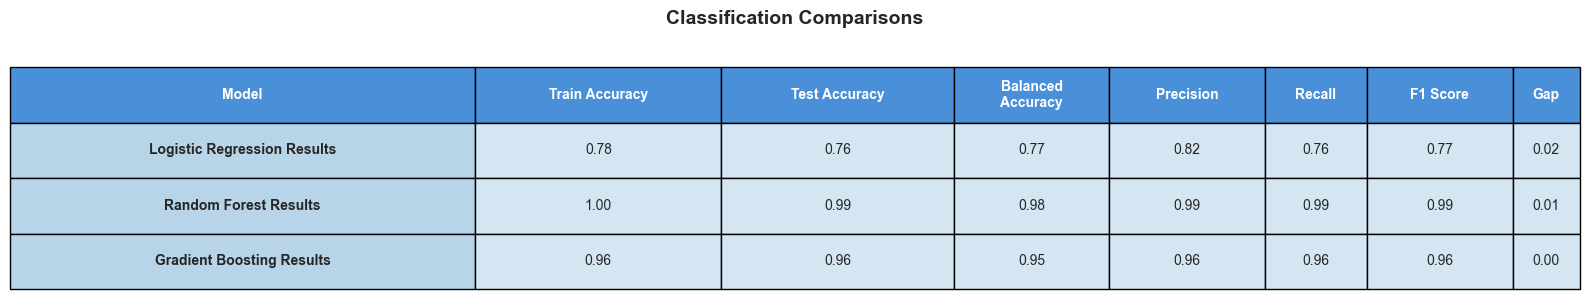

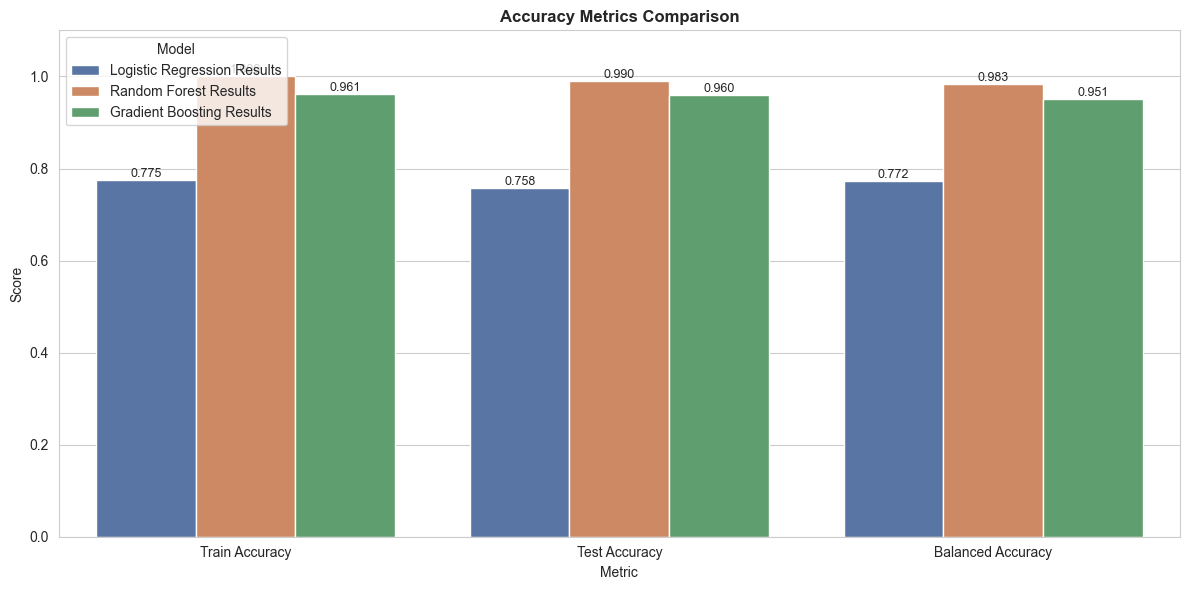

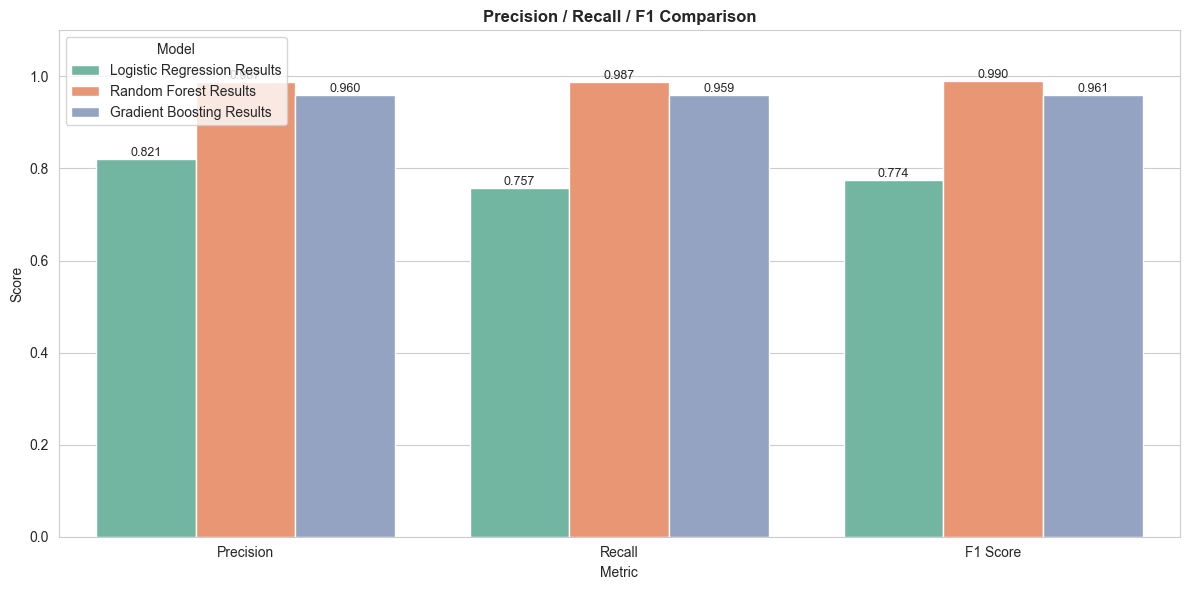

C:\Users\jxbma\AppData\Local\Temp\ipykernel_44208\193104390.py:458: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gap_data, x='Model', y='Gap', palette='deep')


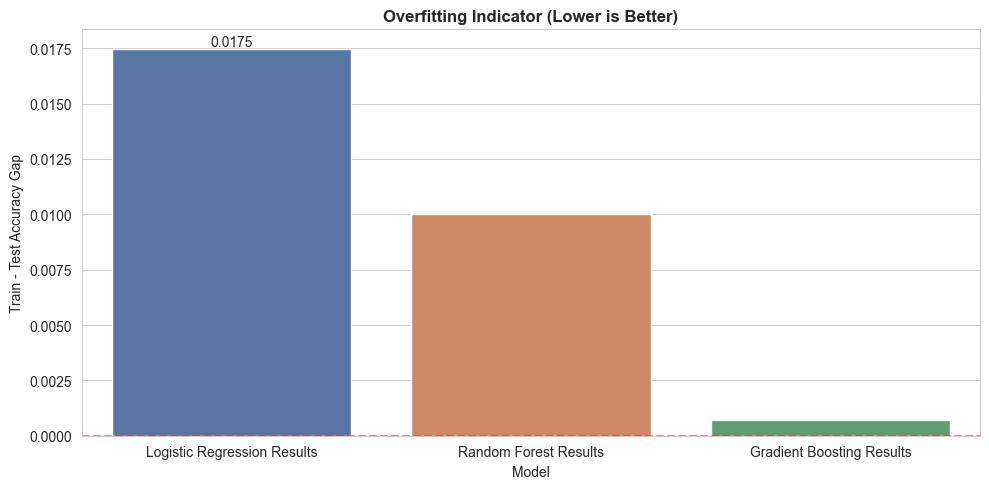

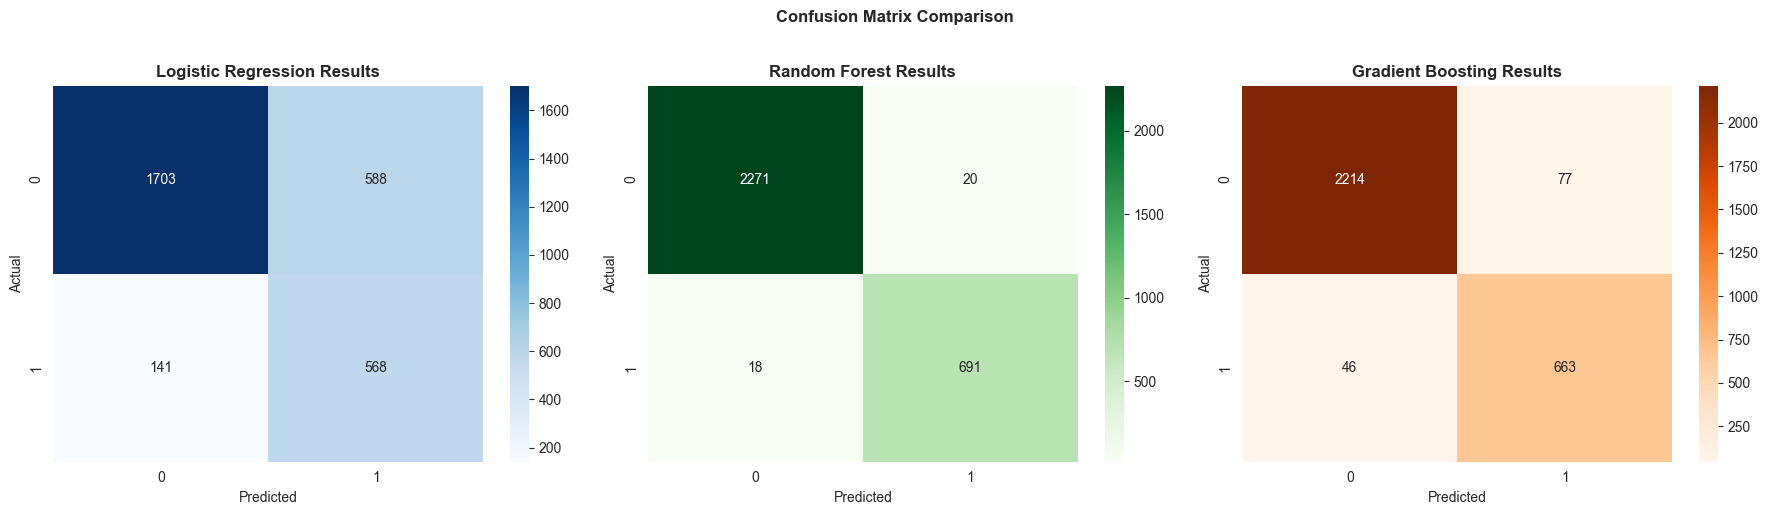

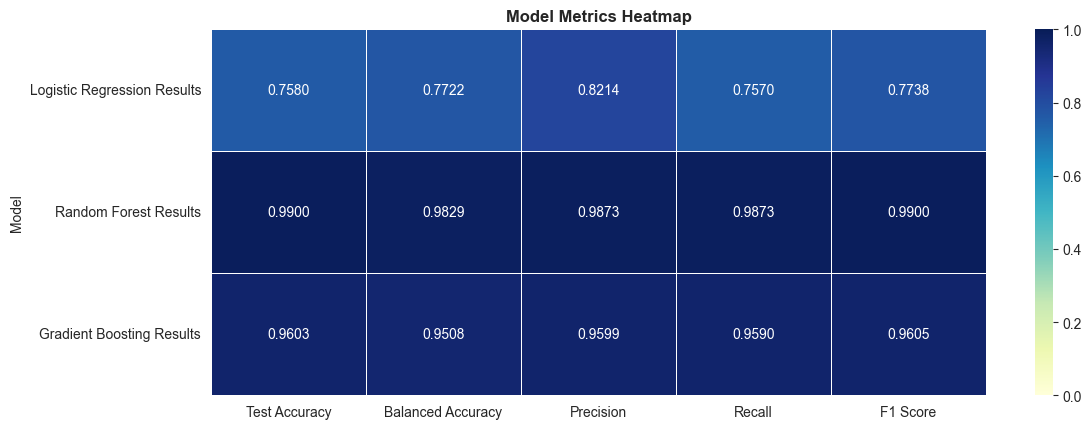

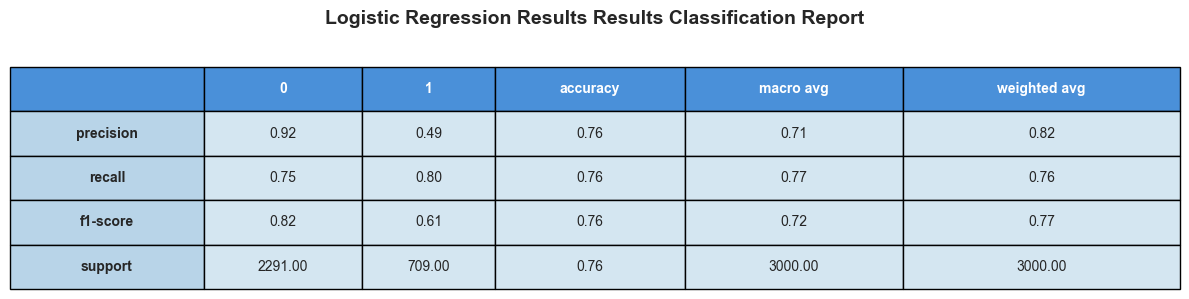

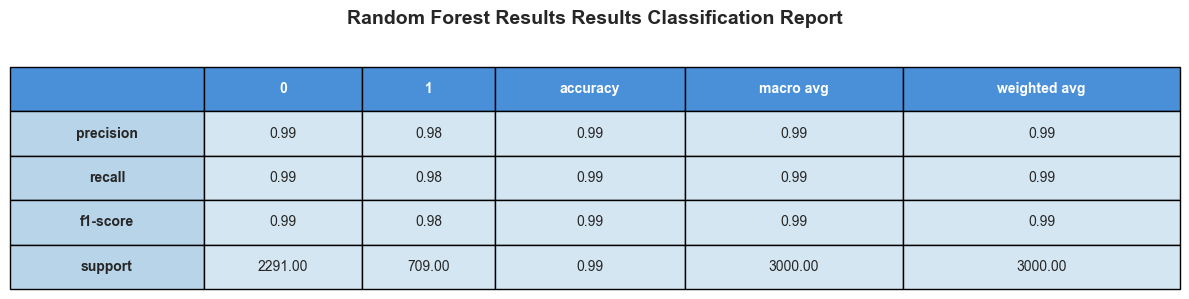

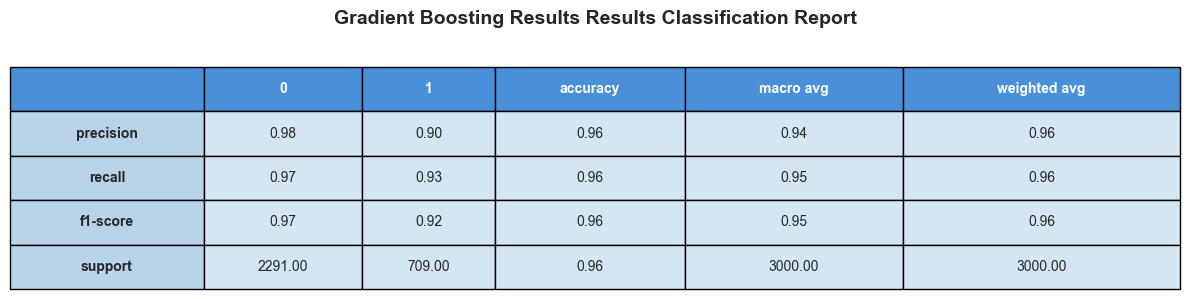

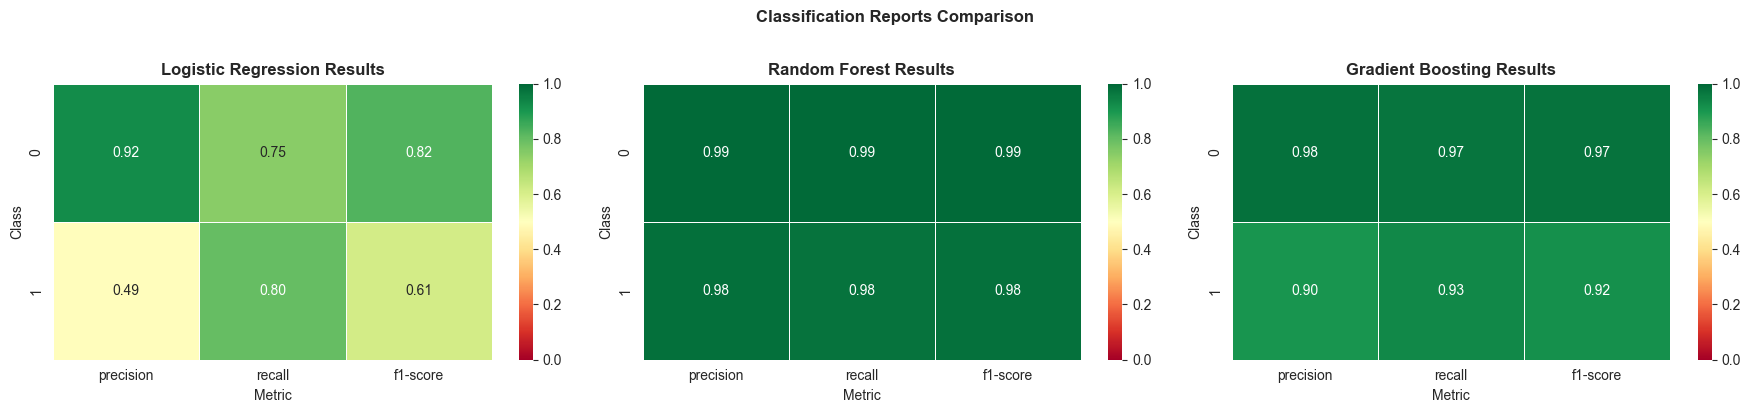

In [54]:
# Display Comparisons

results_dict = {
    'Logistic Regression Results': logisticRegressionResults,
    'Random Forest Results': randomForestResults,
    'Gradient Boosting Results': gradientBoostingResults
}

print('Double check the Classification Results')
df_Results = pd.DataFrame(results_dict)
DisplayTable(df_Results, 'Classification Results')

CompareClassificationResults(results_dict, title='Classification Model Results')
print()
print()


#### **Classification Model Comparisons Analysis** ####

Identify the best model and justify the evaluation metrics used. 

Find the ROC/AUC for each model and plot the ROC curve. 

Find the confusion matrix for each of the models. 

Explain which metric needs to be used from the confusion matrix: Recall or Precision? 